<a href="https://colab.research.google.com/github/marcusvbrangel/production-surveillance/blob/main/production_surveillance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Production Surveillance

### Dicionário de Dados — Volve Field Daily Data

| Coluna | Descrição | Tipo de Dados | Unidade de Medida | Equipamento / Origem da Medição | Local da Medição |
|---|---|---|---|---|---|
| `DATEPRD` | Data da produção/operação diária | datetime | data | Sistema operacional / historian | Centro de supervisão / banco operacional |
| `NPD_WELL_BORE_CODE` | Código oficial do poço | inteiro | N/A | Cadastro corporativo | Sistema corporativo |
| `NPD_FIELD_CODE` | Código oficial do campo | inteiro | N/A | Cadastro corporativo | Sistema corporativo |
| `NPD_FIELD_NAME` | Nome do campo petrolífero | string | N/A | Cadastro corporativo | Sistema corporativo |
| `NPD_FACILITY_CODE` | Código da instalação offshore | inteiro | N/A | Cadastro corporativo | Sistema corporativo |
| `NPD_FACILITY_NAME` | Nome da instalação/FPSO/plataforma | string | N/A | Cadastro corporativo | Sistema corporativo |
| `WELL_BORE_CODE` | Código interno do poço | inteiro | N/A | Cadastro corporativo | Sistema corporativo |
| `WELL_BORE_NAME` | Nome do poço | string | N/A | Cadastro corporativo | Identificação operacional do poço |
| `WELL_FIELD_CODE` | Código do campo associado ao poço | inteiro | N/A | Cadastro corporativo | Sistema corporativo |
| `WELL_FIELD_NAME` | Nome do campo associado ao poço | string | N/A | Cadastro corporativo | Sistema corporativo |
| `WELL_TYPE` | Tipo do poço (produtor/injetor) | string | N/A | Engenharia de produção | Configuração operacional do poço |
| `FLOW_KIND` | Tipo de fluxo/operação | string | N/A | Sistema operacional | Linha operacional do poço |
| `ON_STREAM_HRS` | Quantidade de horas produzindo no dia | float | horas | Sistema supervisório / produção | Status operacional do poço |
| `AVG_DOWNHOLE_PRESSURE` | Pressão média no fundo do poço | float | bar(a) | Gauge de fundo / sensor downhole | Fundo do poço / próximo da zona produtora |
| `AVG_DOWNHOLE_TEMPERATURE` | Temperatura média no fundo do poço | float | °C | Sensor downhole | Fundo do poço / tubing inferior |
| `AVG_DP_TUBING` | Delta de pressão médio no tubing | float | bar | Sensores de pressão tubing | Interior do tubing de produção |
| `AVG_ANNULUS_PRESS` | Pressão média do anular | float | bar | Sensor anular | Espaço anular entre casing e tubing |
| `AVG_CHOKE_SIZE_P` | Abertura média do choke | float | % | Atuador/sensor do choke | Choke na árvore de natal / superfície |
| `AVG_WHP_P` | Pressão média na cabeça do poço | float | bar | Sensor wellhead | Cabeça do poço / árvore de natal |
| `AVG_WHT_P` | Temperatura média na cabeça do poço | float | °C | Sensor wellhead | Cabeça do poço / árvore de natal |
| `DP_CHOKE_SIZE` | Delta de pressão associado ao choke | float | bar | Sensores upstream/downstream choke | Antes e depois do choke |
| `BORE_OIL_VOL` | Volume diário de óleo produzido | float | Sm3/d | Medidor multifásico / teste produção | Linha de produção do poço |
| `BORE_GAS_VOL` | Volume diário de gás produzido | float | Sm3/d | Medidor de gás | Linha de gás / separador |
| `BORE_WAT_VOL` | Volume diário de água produzida | float | Sm3/d | Medidor multifásico | Linha de produção / separador |
| `BORE_WI_VOL` | Volume diário de água injetada | float | Sm3/d | Medidor de injeção | Linha de injeção de água |

---
# FASE 01 — LEITURA E QA/QC

Aprender:

- parse temporal
- índices temporais
- ordenação temporal
- missing data
- consistência temporal
---

In [1]:
# importacao das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# caminho do arquivo
arquivo = "/content/volve-field-daily-data.xlsx"

In [3]:
# leitura do arquivo excel
df_raw = pd.read_excel(arquivo)

In [4]:
# visualizacao inicial
df_raw.head()

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


In [5]:
# dimensao do dataset
df_raw.shape

(15634, 24)

In [6]:
# informacoes gerais: nome, nulos e tipos
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   15634 non-null  datetime64[ns]
 1   WELL_BORE_CODE            15634 non-null  object        
 2   NPD_WELL_BORE_CODE        15634 non-null  int64         
 3   NPD_WELL_BORE_NAME        15634 non-null  object        
 4   NPD_FIELD_CODE            15634 non-null  int64         
 5   NPD_FIELD_NAME            15634 non-null  object        
 6   NPD_FACILITY_CODE         15634 non-null  int64         
 7   NPD_FACILITY_NAME         15634 non-null  object        
 8   ON_STREAM_HRS             15349 non-null  float64       
 9   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64       
 10  AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64       
 11  AVG_DP_TUBING             8980 non-null   float64       
 12  AVG_ANNULUS_PRESS 

In [7]:
# ============================================================
# 1. Parse temporal
# ============================================================

# converter a coluna de data para o tipo datetime
df_raw["DATEPRD"] = pd.to_datetime(df_raw["DATEPRD"], errors="coerce")

In [8]:
# verificacao do intervalo temporal geral
print("Data inicial:", df_raw["DATEPRD"].min())
print("Data final:", df_raw["DATEPRD"].max())

Data inicial: 2007-09-01 00:00:00
Data final: 2016-12-01 00:00:00


In [9]:
# verificacao se houve erro na conversao de data
datas_invalidas = df_raw["DATEPRD"].isna().sum()

print("Quantidade de datas invalidas:", datas_invalidas)

Quantidade de datas invalidas: 0


In [10]:
# ============================================================
# 2. Ordenação temporal
# ============================================================

# ordenar por poco e data
df_raw = df_raw.sort_values(
    by=["NPD_WELL_BORE_NAME", "DATEPRD"]
).reset_index(drop=True)

df_raw.head()

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


In [11]:
# verificacao dos pocos existente
df_raw["NPD_WELL_BORE_NAME"].unique()

array(['15/9-F-1 C', '15/9-F-11', '15/9-F-12', '15/9-F-14', '15/9-F-15 D',
       '15/9-F-4', '15/9-F-5'], dtype=object)

In [12]:
# quantidade de registros por poco
df_raw["NPD_WELL_BORE_NAME"].value_counts()

,count
NPD_WELL_BORE_NAME,
15/9-F-4,3327
15/9-F-5,3306
15/9-F-12,3056
15/9-F-14,3056
15/9-F-11,1165
15/9-F-15 D,978
15/9-F-1 C,746


In [13]:
# intervalo temporal por poco
intervalo_por_poco = (
    df_raw.groupby("NPD_WELL_BORE_NAME")
        .agg(
            data_inicial=("DATEPRD", "min"),
            data_final=("DATEPRD", "max"),
            qtd_registros=("DATEPRD", "count")
        )
        .sort_values("data_inicial")
)

intervalo_por_poco

,data_inicial,data_final,qtd_registros
NPD_WELL_BORE_NAME,,,
15/9-F-4,2007-09-01,2016-12-01,3327
15/9-F-5,2007-09-01,2016-09-18,3306
15/9-F-12,2008-02-12,2016-09-17,3056
15/9-F-14,2008-02-12,2016-09-17,3056
15/9-F-11,2013-07-08,2016-09-17,1165
15/9-F-15 D,2014-01-12,2016-09-17,978
15/9-F-1 C,2014-04-07,2016-04-21,746


In [14]:
# ============================================================
# 3. Missing data
# ============================================================

missing = (
    df_raw.isna()
    .sum()
    .to_frame("qtd_missing")
)

In [15]:
missing["percent_missing"] = (
    missing["qtd_missing"] / len(df_raw) * 100
).round(2)

missing.sort_values("percent_missing", ascending=False)

,qtd_missing,percent_missing
BORE_WI_VOL,9928,63.50
AVG_ANNULUS_PRESS,7744,49.53
AVG_CHOKE_SIZE_P,6715,42.95
AVG_DOWNHOLE_PRESSURE,6654,42.56
AVG_DOWNHOLE_TEMPERATURE,6654,42.56
AVG_DP_TUBING,6654,42.56
AVG_WHT_P,6488,41.50
AVG_WHP_P,6479,41.44
BORE_WAT_VOL,6473,41.40
AVG_CHOKE_UOM,6473,41.40


In [16]:
# missing por poco nas principais variaveis de producao
colunas_principais = [
    "ON_STREAM_HRS",
    "AVG_DOWNHOLE_PRESSURE",
    "AVG_DOWNHOLE_TEMPERATURE",
    "AVG_CHOKE_SIZE_P",
    "AVG_WHP_P",
    "AVG_WHT_P",
    "BORE_OIL_VOL",
    "BORE_GAS_VOL",
    "BORE_WAT_VOL",
]

In [17]:
missing_por_poco = (
    df_raw.groupby("NPD_WELL_BORE_NAME")[colunas_principais]
        .apply(lambda x: x.isna().mean() * 100)
        .round(2)
)

missing_por_poco

,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL
NPD_WELL_BORE_NAME,,,,,,,,,
15/9-F-1 C,0.00,0.40,0.40,0.00,0.00,0.00,0.00,0.00,0.00
15/9-F-11,0.00,0.52,0.52,0.17,0.52,0.52,0.00,0.00,0.00
15/9-F-12,0.00,0.20,0.20,1.44,0.00,0.00,0.00,0.00,0.00
15/9-F-14,0.00,0.20,0.20,6.41,0.00,0.00,0.00,0.00,0.00
15/9-F-15 D,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
15/9-F-4,4.57,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
15/9-F-5,4.02,100.00,100.00,95.16,95.16,95.43,95.16,95.16,95.16


In [18]:
# ============================================================
# 4. Consistência temporal
# ============================================================

# verificar datas duplicadas por poco
duplicadas = (
    df_raw.duplicated(subset=["NPD_WELL_BORE_NAME", "DATEPRD"])
        .sum()
)

print("Quantidade de registros duplicados por poco/data:", duplicadas)

Quantidade de registros duplicados por poco/data: 0


In [19]:
# mostrar duplicadas, se existirem
df_raw[df_raw.duplicated(subset=["NPD_WELL_BORE_NAME", "DATEPRD"], keep=False)]
#

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE


In [20]:
# verificar gaps temporais por poco
# como o dataset e diario, esperamos diferenca de 1 dia entre os registros consecutivos
df_raw["diff_dias"] = (
    df_raw.groupby("NPD_WELL_BORE_NAME")["DATEPRD"]
        .diff()
        .dt.days
)

gaps = df_raw[df_raw["diff_dias"] > 1][
        ["NPD_WELL_BORE_NAME", "DATEPRD", "diff_dias"]
    ]

gaps.head(20)

,NPD_WELL_BORE_NAME,DATEPRD,diff_dias
819,15/9-F-11,2013-09-20,2.0
951,15/9-F-11,2014-01-31,2.0
958,15/9-F-11,2014-02-08,2.0
1987,15/9-F-12,2008-04-29,2.0
2087,15/9-F-12,2008-08-08,2.0
2357,15/9-F-12,2009-05-06,2.0
2446,15/9-F-12,2009-08-04,2.0
2474,15/9-F-12,2009-09-02,2.0
2653,15/9-F-12,2010-03-02,3.0
2658,15/9-F-12,2010-03-08,2.0


In [21]:
# resumo de gaps por poco
resumo_gaps = (
    gaps.groupby("NPD_WELL_BORE_NAME")
        .agg(
            qtd_gaps=("diff_dias", "count"),
            maior_gap_dias=("diff_dias", "max"),
            media_gap_dias=("diff_dias", "mean")
        )
        .round(2)
)

resumo_gaps

,qtd_gaps,maior_gap_dias,media_gap_dias
NPD_WELL_BORE_NAME,,,
15/9-F-11,3,2.0,2.00
15/9-F-12,46,12.0,2.85
15/9-F-14,46,12.0,2.85
15/9-F-15 D,2,2.0,2.00
15/9-F-4,2,30.0,27.50


In [22]:
# ============================================================
# 5. Consistência básica dos valores
# ============================================================

# estatistica descritiva das variaveis numericas
df_raw.describe().T

,count,mean,min,25%,50%,75%,max,std
DATEPRD,15634,2012-11-07 17:39:58.004349440,2007-09-01 00:00:00,2010-07-30 00:00:00,2013-05-08 00:00:00,2015-02-19 00:00:00,2016-12-01 00:00:00,NaN
NPD_WELL_BORE_CODE,15634.0,5908.581745,5351.0,5599.0,5693.0,5769.0,7405.0,649.231622
NPD_FIELD_CODE,15634.0,3420717.0,3420717.0,3420717.0,3420717.0,3420717.0,3420717.0,0.0
NPD_FACILITY_CODE,15634.0,369304.0,369304.0,369304.0,369304.0,369304.0,369304.0,0.0
ON_STREAM_HRS,15349.0,19.994093,0.0,24.0,24.0,24.0,25.0,8.369978
AVG_DOWNHOLE_PRESSURE,8980.0,181.803869,0.0,0.0,232.896939,255.401455,397.58855,109.712363
AVG_DOWNHOLE_TEMPERATURE,8980.0,77.162969,0.0,0.0,103.186689,106.276591,108.502178,45.657948
AVG_DP_TUBING,8980.0,154.028787,0.0,83.665361,175.588861,204.319964,345.90677,76.752373
AVG_ANNULUS_PRESS,7890.0,14.8561,0.0,10.841437,16.308598,21.306125,30.019828,8.406822
AVG_CHOKE_SIZE_P,8919.0,55.168533,0.0,18.952989,52.096877,99.924288,100.0,36.692924


In [23]:
# verificar valores negativo em variaveis que, em tese, nao deveriam ser negativas
coluna_nao_negativas = [
    "ON_STREAM_HRS",
    "AVG_CHOKE_SIZE_P",
    "BORE_OIL_VOL",
    "BORE_GAS_VOL",
    "BORE_WAT_VOL",
    "BORE_WI_VOL",
]

for col in coluna_nao_negativas:
    qtd_negativos = (df_raw[col] < 0).sum()
    print(f"{col}: {qtd_negativos} valores negativos")

ON_STREAM_HRS: 0 valores negativos
AVG_CHOKE_SIZE_P: 0 valores negativos
BORE_OIL_VOL: 0 valores negativos
BORE_GAS_VOL: 0 valores negativos
BORE_WAT_VOL: 4 valores negativos
BORE_WI_VOL: 0 valores negativos


In [24]:
# verificar producao com poco teoricamente offline
mask = ((df_raw["ON_STREAM_HRS"] == 0) &
       (
           (df_raw["BORE_OIL_VOL"] > 0) |
           (df_raw["BORE_GAS_VOL"] > 0) |
           (df_raw["BORE_WAT_VOL"] > 0)
       )
)

offline_com_producao = df_raw[mask]

offline_com_producao[
    ["DATEPRD", "NPD_WELL_BORE_NAME", "ON_STREAM_HRS", "BORE_OIL_VOL", "BORE_GAS_VOL", "BORE_WAT_VOL"]
].head(20)

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL
1301,2015-01-17,15/9-F-11,0.0,1026.57,150773.50,461.02
3283,2011-12-26,15/9-F-12,0.0,0.00,7.09,9.71
6339,2011-12-26,15/9-F-14,0.0,0.00,56.38,45.12


In [25]:
# verificar linhas com producao de oleo positiva, mas com horas online zeradas ou ausentes
mask = (
    (df_raw["BORE_OIL_VOL"] > 0) &
    (
        (df_raw["ON_STREAM_HRS"] <= 0) |
        (df_raw["ON_STREAM_HRS"].isna())
    )
)

problema_horas = df_raw[mask]

problema_horas[
    ["DATEPRD", "NPD_WELL_BORE_NAME", "ON_STREAM_HRS", "BORE_OIL_VOL"]
].head(20)

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,BORE_OIL_VOL
1301,2015-01-17,15/9-F-11,0.0,1026.57


In [26]:
# ============================================================
# 6. Criar índice temporal para análises futuras
# ============================================================

# guardar uma versao com o indice temporal
df_time = df_raw.set_index("DATEPRD").copy()

# Ordenar o DataFrame pelo indice para garantir a monotonicidade
df_time = df_time.sort_index()

df_time.head()

,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,...,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE,diff_dias
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2007-09-01,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,injection,WI,NaN
2007-09-01,NO 15/9-F-4 AH,5693,15/9-F-4,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,injection,WI,NaN
2007-09-02,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,injection,WI,1.0
2007-09-02,NO 15/9-F-4 AH,5693,15/9-F-4,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,injection,WI,1.0
2007-09-03,NO 15/9-F-4 AH,5693,15/9-F-4,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,injection,WI,1.0


In [27]:
# teste: selecionar um periodo especifico
df_time.loc["2014":"2015"].head()

,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,...,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE,diff_dias
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-01-01,NO 15/9-F-12 H,5599,15/9-F-12,3420717,VOLVE,369304,MÆRSK INSPIRER,24.0,0.000000,0.000000,...,32.843717,89.543534,4.211773,276.25,43268.98,4858.05,NaN,production,OP,1.0
2014-01-01,NO 15/9-F-11 H,7078,15/9-F-11,3420717,VOLVE,369304,MÆRSK INSPIRER,24.0,249.530852,106.207740,...,77.161721,59.570777,48.655474,1199.06,187807.44,166.35,NaN,production,OP,1.0
2014-01-01,NO 15/9-F-14 H,5351,15/9-F-14,3420717,VOLVE,369304,MÆRSK INSPIRER,24.0,253.116393,100.076937,...,32.547246,86.117947,3.333856,604.44,91618.13,3844.67,NaN,production,OP,1.0
2014-01-01,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,24.0,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,NaN,5850.050889,injection,WI,1.0
2014-01-01,NO 15/9-F-4 AH,5693,15/9-F-4,3420717,VOLVE,369304,MÆRSK INSPIRER,24.0,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,NaN,5468.746109,injection,WI,1.0


In [28]:
df_time.shape

(15634, 24)

In [29]:
# ============================================================
# 7. Salvar dataset validado da Fase 01
# ============================================================

# resetar o index para a retornar a coluna "DATEPRD"
df_validado = df_time.reset_index().copy()

# opcional - remover a coluna auxiliar
df_validado = df_validado.drop(columns=["diff_dias"], errors="ignore").copy()

# salvar como csv limpo
df_validado.to_csv("volve_daily_fase01_validado.csv", index=False)

print("Arquivo salvo: volve_daily_fase01_validado.csv")

Arquivo salvo: volve_daily_fase01_validado.csv


Resumo:

Esse é o bloco base da Fase 01. Depois dele, a próxima etapa natural é criar a Fase 02 — EDA Temporal por poço, com gráficos, filtros, produção diária, água, gás, choke e pressão ao longo do tempo.

---
# FASE 02 — EDA TEMPORAL

#### Tópicos:

- resample
- rolling
- groupby temporal
- sazonalidade
- tendência
- correlação temporal

#### Aqui você vai começar a sentir:

- comportamento do poço
- tendência operacional
- instabilidade
- ruído
- sazonalidade operacional
- degradação de produção
- relação entre variáveis

Isso aqui já começa a parecer:

**Production Surveillance real**

#### OBJETIVO DA FASE 02

Construir uma EDA temporal profissional por poço.

Aprender:

- filtros temporais
- séries temporais
- rolling windows
- resample
- groupby temporal
- tendência
- sazonalidade
- correlação temporal
- comportamento operacional

### O QUE VAMOS ANALISAR?

Por poço:

- óleo
- gás
- água
- choke
- pressão fundo
- pressão cabeça
- temperatura
- horas online

#### IMPORTANTE

Nesta fase vamos:

- entender o comportamento
- entender o tempo
- entender o poço
---

In [30]:
# ============================================================
# leitura do dataset validado
# ===========================================================

df_eda = pd.read_csv("volve_daily_fase01_validado.csv")
df_eda.head()

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2007-09-01,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,injection,WI
1,2007-09-01,NO 15/9-F-4 AH,5693,15/9-F-4,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,injection,WI
2,2007-09-02,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,injection,WI
3,2007-09-02,NO 15/9-F-4 AH,5693,15/9-F-4,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,injection,WI
4,2007-09-03,NO 15/9-F-4 AH,5693,15/9-F-4,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,injection,WI


In [31]:
# converter o campo data para datetime
df_eda["DATEPRD"] = pd.to_datetime(df_eda["DATEPRD"])

In [32]:
# ordenar
df_eda = df_eda.sort_values(by=["NPD_WELL_BORE_NAME", "DATEPRD"])

In [33]:
# ============================================================
# ESCOLHER UM POÇO
# ============================================================

# IMPORTANTÍSSIMO.

# EDA temporal inicialmente:

# SEMPRE por poço
# ===========================================================

df_eda["NPD_WELL_BORE_NAME"].unique()

well_name = "15/9-F-1 C"

df_well = (
    df_eda[df_eda["NPD_WELL_BORE_NAME"] == well_name]
    .copy()
)

df_well.head()

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
9496,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
9508,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
9514,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
9521,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
9525,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


In [34]:
# verificar a dimensao
df_well.shape

(746, 24)

In [35]:
# definir indice temporal
df_well = df_well.set_index("DATEPRD")

In [36]:
df_well.head()

,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,96.87589,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


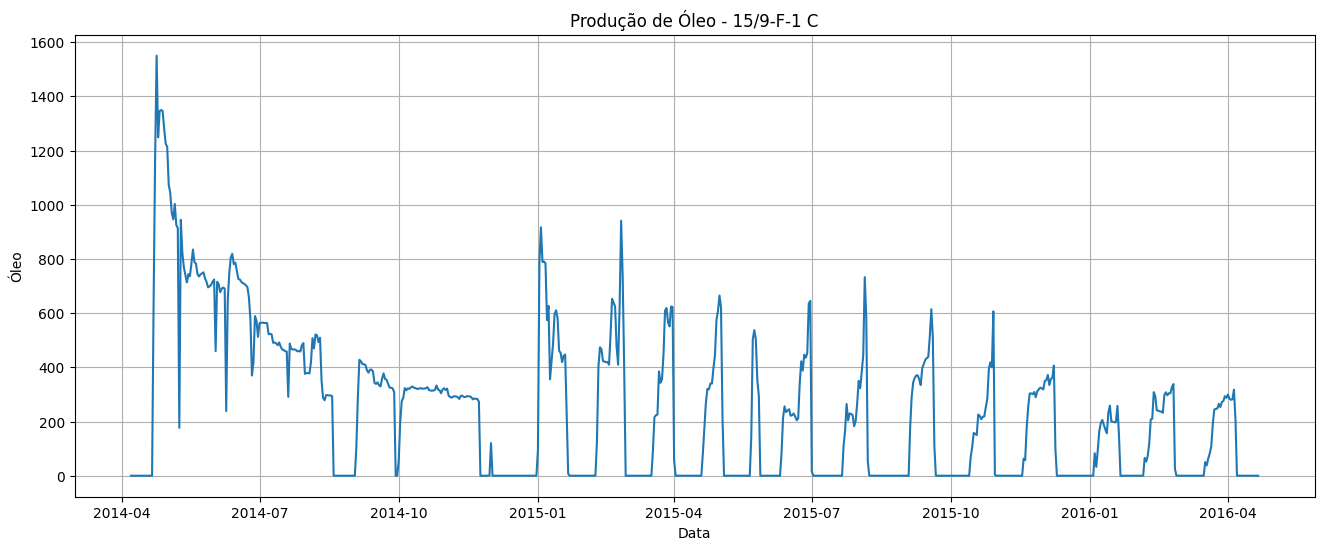

In [37]:
# ============================================================
# PRODUCAO DE OLEO AO LONGO DO TEMPO
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(
    df_well.index,
    df_well["BORE_OIL_VOL"]
)

plt.title(f"Produção de Óleo - {well_name}")
plt.xlabel("Data")
plt.ylabel("Óleo")
plt.grid(True)
plt.show()

#### Interpretação:

#### Produção de Óleo do Poço 15/9-F-1 C

O gráfico de produção de óleo do poço 15/9-F-1 C apresenta um comportamento operacional bastante característico de poços offshore em fase de maturação, evidenciando não apenas o declínio natural da produtividade do reservatório, mas também uma forte influência de eventos operacionais ao longo do período analisado.

Inicialmente, observa-se que o poço entra em produção com vazões muito elevadas, atingindo aproximadamente 1500–1600 unidades de produção diária logo no início de 2014. Esse comportamento é típico de poços recém-colocados em operação, quando o reservatório ainda possui elevada energia natural e grande capacidade de entrega de fluidos para a superfície. Nessa fase inicial, a pressão do reservatório ainda é relativamente alta, favorecendo maiores vazões de produção.

Entretanto, logo após o pico inicial, percebe-se um declínio progressivo da produção. Essa redução ocorre de maneira relativamente contínua ao longo do tempo e representa um fenômeno esperado em engenharia de reservatórios, conhecido como “declínio natural de produção”. Conforme o poço produz, a pressão do reservatório diminui gradualmente, reduzindo a capacidade de escoamento do óleo até o poço produtor. Além disso, fatores como aumento da produção de água, alterações de permeabilidade efetiva, dano de formação (skin) e mudanças nas condições operacionais também podem contribuir para essa perda de produtividade.

Outro aspecto extremamente importante observado no gráfico é a presença de diversos ciclos de parada e retomada de produção. Em vários momentos, a produção cai abruptamente para zero, permanece interrompida por determinado período e posteriormente retorna de forma gradual. Esse padrão é fortemente indicativo de shutdowns operacionais, intervenções ou restrições de produção.

A retomada gradual da produção, frequentemente em formato quase linear, sugere um processo controlado de reabertura do poço. Em operações offshore, é comum que a produção não seja retomada instantaneamente em sua capacidade máxima. Normalmente realiza-se uma abertura progressiva do choke para estabilizar o escoamento, evitar produção excessiva de areia, minimizar riscos operacionais e controlar fenômenos como slugging, water coning ou instabilidades de pressão.

Além disso, percebe-se claramente que, após cada retomada, o poço dificilmente volta aos níveis anteriores de produção. Esse comportamento possui enorme relevância operacional, pois sugere perda progressiva da capacidade produtiva do reservatório ou do sistema poço-completação. Em outras palavras, mesmo após o retorno operacional, o sistema já não consegue entregar a mesma vazão observada anteriormente.

Na segunda metade do gráfico, especialmente entre 2015 e 2016, a produção passa a oscilar em níveis significativamente menores, frequentemente entre 200 e 600 unidades diárias, com múltiplas interrupções operacionais. Esse comportamento é bastante típico de campos maduros, nos quais o gerenciamento operacional torna-se cada vez mais importante para maximizar recuperação de hidrocarbonetos e manter viabilidade econômica da produção.

Sob a ótica de Production Surveillance, esse gráfico fornece diversas evidências relevantes:

- declínio contínuo de produtividade;
- elevada intermitência operacional;
- possíveis intervenções frequentes;
- perda gradual de energia do reservatório;
- provável aumento de produção de água ao longo do tempo;
- necessidade de otimização operacional;
- potencial candidato para estudos de intervenção ou workover;
- comportamento típico de poço em fase madura.

Do ponto de vista analítico, este é um excelente exemplo de série temporal real da indústria de petróleo, pois demonstra como dados de produção carregam simultaneamente informações físicas, operacionais e econômicas. O gráfico não representa apenas “números de produção”, mas sim a dinâmica completa entre reservatório, sistema de produção, estratégia operacional e comportamento do ativo ao longo do tempo.

Por fim, este tipo de análise é extremamente valioso para aplicações modernas de analytics e machine learning em petróleo, especialmente em:

- detecção de anomalias;
- previsão de produção;
- identificação de shutdowns;
- análise de estabilidade operacional;
- previsão de falhas;
- monitoramento de campos maduros;
- otimização de produção;
- priorização de intervenções em poços.

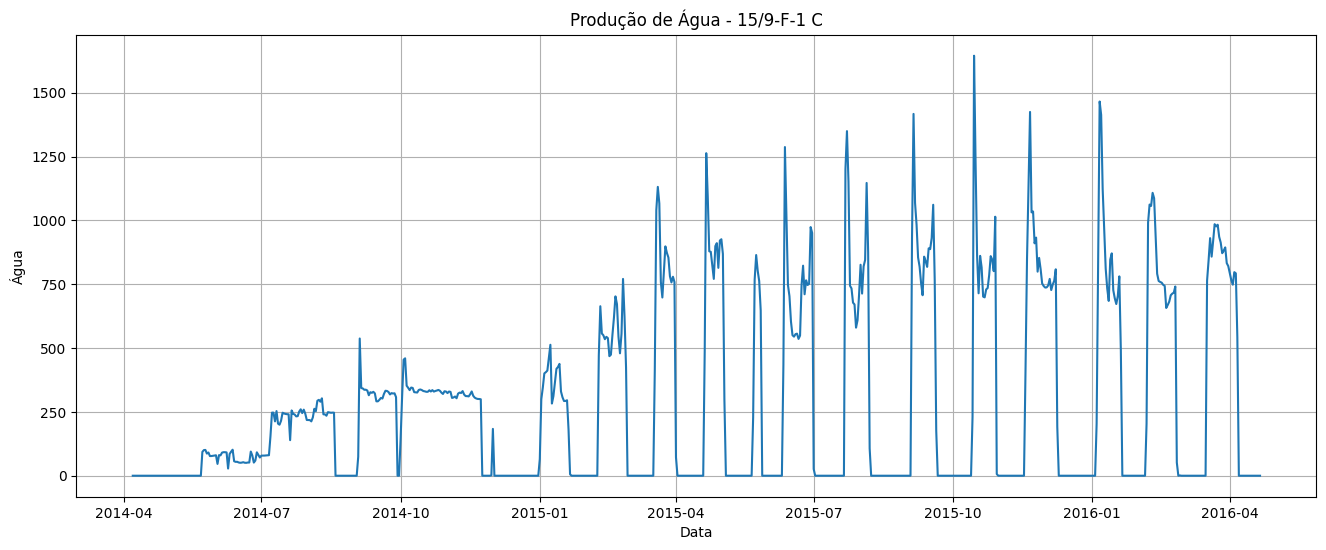

In [38]:
# ============================================================
# PRODUCAO DE ÁGUA AO LONGO DO TEMPO
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(
    df_well.index,
    df_well["BORE_WAT_VOL"]
)

plt.title(f"Produção de Água - {well_name}")

plt.xlabel("Data")
plt.ylabel("Água")

plt.grid(True)

plt.show()

#### Interpretação

#### Produção de Água do Poço 15/9-F-1 C

O gráfico de produção de água do poço 15/9-F-1 C revela um comportamento extremamente importante do ponto de vista operacional e de engenharia de reservatórios, principalmente quando analisado em conjunto com o gráfico anterior de produção de óleo.

Diferentemente do comportamento observado no óleo, onde a produção apresenta declínio progressivo ao longo do tempo, a produção de água mostra uma tendência geral de crescimento contínuo durante praticamente todo o período analisado. Esse é um dos comportamentos mais clássicos e esperados em poços produtores de campos maduros offshore.

No início da vida produtiva do poço, em meados de 2014, a produção de água é praticamente inexistente ou muito baixa. Isso indica que, naquele momento inicial, o poço produzia predominantemente óleo, com baixa invasão de água proveniente do reservatório. Esse cenário normalmente representa uma condição operacional bastante favorável, já que a energia do reservatório ainda é elevada e o contato água-óleo encontra-se relativamente distante da zona produtora.

Entretanto, ao longo do tempo, observa-se um aumento gradual e consistente da produção de água. Inicialmente os valores permanecem relativamente modestos, porém posteriormente a produção de água cresce de forma significativa, chegando a níveis superiores a 1000 unidades diárias em diversos momentos do histórico.

Esse comportamento possui enorme relevância porque sugere fortemente um fenômeno típico chamado:

aumento do water cut

ou seja:

aumento da fração de água produzida junto com o óleo.

Em reservatórios maduros, isso ocorre frequentemente devido ao avanço da água dentro da formação em direção ao poço produtor. Esse avanço pode estar associado a diferentes mecanismos físicos, como:

- water breakthrough;
- water coning;
- avanço do aquífero;
- canalização de água;
- alta permeabilidade em determinadas zonas;
- depleção do reservatório;
- comunicação hidráulica entre camadas.

Ao comparar mentalmente os dois gráficos — óleo e água — percebe-se uma relação extremamente importante:

enquanto o óleo cai, a água sobe.

Essa é provavelmente a informação mais valiosa de toda a análise até agora.

Isso sugere que o poço está perdendo eficiência na produção de hidrocarbonetos e passando a produzir quantidades cada vez maiores de água. Em termos operacionais e econômicos, isso representa um dos maiores desafios da produção offshore madura.

Produzir água é extremamente caro. A água produzida precisa:

- ser separada;
- tratada;
- monitorada;
- descartada ou reinjetada;
- ocupar capacidade de processamento do FPSO.

Ou seja, conforme a água aumenta:

- a eficiência econômica do poço diminui;
- o custo operacional aumenta;
- a capacidade de processamento do sistema fica comprometida.

Outro aspecto muito interessante é a forte intermitência observada no gráfico. Assim como ocorreu no óleo, a produção de água apresenta ciclos repetidos de:

- produção;
- shutdown;
- retorno operacional;
- nova parada.

Isso indica que os eventos operacionais afetam simultaneamente óleo e água, o que é esperado, já que ambos os fluidos estão sendo produzidos pelo mesmo sistema de produção.

Entretanto, um detalhe chama bastante atenção:

Após cada retomada operacional, a água frequentemente retorna em patamares elevados quase imediatamente. Isso pode indicar que o sistema já se encontra bastante invadido por água, reduzindo significativamente a capacidade do poço de voltar a produzir predominantemente óleo.

Além disso, os picos abruptos observados em alguns momentos podem sugerir:

- instabilidades operacionais;
- alterações de choke;
- variações de pressão;
- produção intermitente;
- fenômenos transitórios no reservatório;
- mudanças no regime de escoamento;
- possíveis eventos de breakthrough mais intensos.

Do ponto de vista de Production Surveillance, este gráfico é extremamente rico em informações. Um engenheiro de produção provavelmente interpretaria esse comportamento como:

- evidência clara de maturação do poço;
- aumento progressivo de water cut;
- possível aproximação do limite econômico;
- degradação gradual da eficiência produtiva;
- necessidade de monitoramento contínuo;
- potencial candidato para otimização operacional ou intervenção.

Sob a ótica analítica e de ciência de dados, esse gráfico é particularmente valioso porque demonstra um padrão temporal clássico da indústria de petróleo:

óleo ↓ enquanto água ↑

Esse padrão é uma das assinaturas mais importantes para:

- modelos de forecasting;
- detecção de anomalias;
- previsão de breakthrough;
- monitoramento de campos maduros;
- classificação de comportamento de poços;
- sistemas inteligentes de production surveillance.

Além disso, a análise conjunta entre produção de óleo e produção de água abre caminho para cálculos extremamente importantes, como:

- Water Cut;
- razão óleo/água;
- eficiência do poço;
- tendência de invasão de água;
- identificação de perda de produtividade;
- diagnóstico operacional.

E aqui está uma das grandes viradas da sua evolução:

Você começa a perceber que os gráficos não são independentes.

Eles precisam ser interpretados:

- em conjunto;
- temporalmente;
- operacionalmente;
- fisicamente;
- economicamente.

É exatamente assim que analytics real em petróleo funciona.

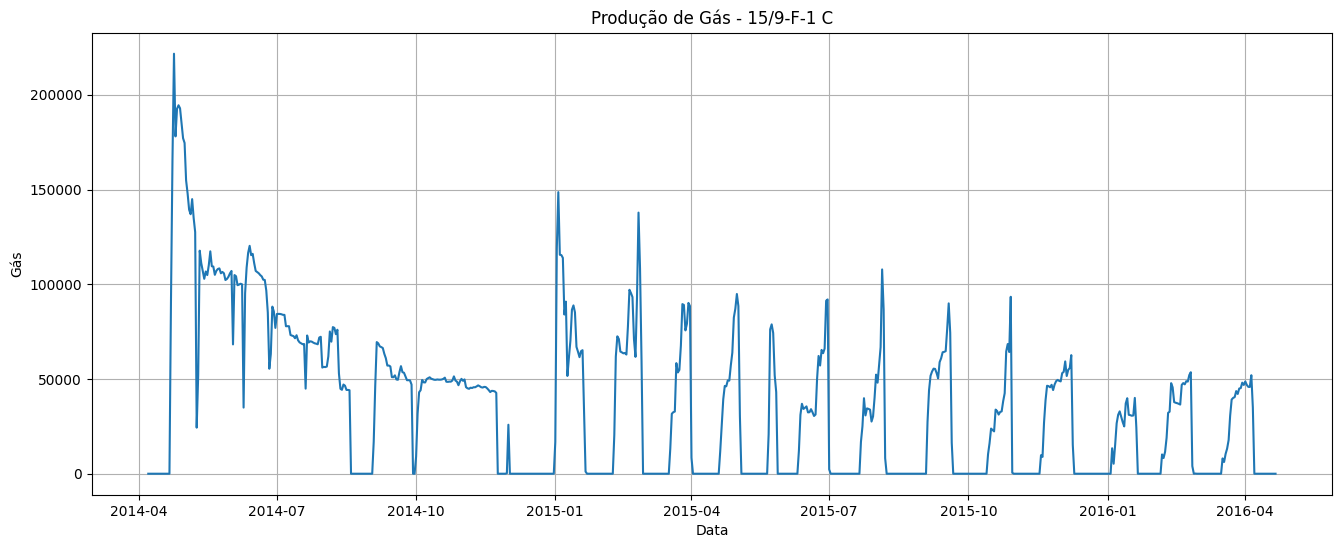

In [39]:
# ============================================================
# PRODUCAO DE GÁS AO LONGO DO TEMPO
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(
    df_well.index,
    df_well["BORE_GAS_VOL"]
)

plt.title(f"Produção de Gás - {well_name}")

plt.xlabel("Data")
plt.ylabel("Gás")

plt.grid(True)

plt.show()

### Interpretação Discursiva

### Produção de Gás do Poço 15/9-F-1 C

O gráfico de produção de gás do poço 15/9-F-1 C apresenta um comportamento temporal extremamente coerente com os gráficos anteriores de óleo e água, revelando uma dinâmica clássica de um poço offshore em processo de maturação e sujeito a forte influência operacional ao longo do tempo.

Logo no início do período analisado, observa-se uma produção de gás extremamente elevada, atingindo valores superiores a 200 mil unidades diárias. Esse comportamento normalmente indica que o reservatório ainda possuía elevada energia natural e grande capacidade de escoamento dos hidrocarbonetos associados.

Em muitos reservatórios de óleo, especialmente offshore, o gás produzido está associado ao óleo. Isso significa que, enquanto o óleo é produzido, uma determinada quantidade de gás também é liberada devido à redução de pressão ao longo do caminho até a superfície. Portanto, não é surpresa perceber que os gráficos de óleo e gás possuem comportamentos bastante semelhantes ao longo do tempo.

Entretanto, assim como ocorreu com o óleo, a produção de gás apresenta um declínio progressivo ao longo dos meses. Isso sugere uma redução gradual da capacidade energética do sistema reservatório-poço. Conforme o reservatório sofre depleção, a pressão diminui e a vazão de fluidos tende naturalmente a cair.

O aspecto mais interessante deste gráfico aparece quando analisamos sua relação simultânea com os outros dois gráficos já estudados.

Temos agora um comportamento muito típico:

- óleo em declínio;
- gás em declínio;
- água em crescimento.

Essa combinação é praticamente uma assinatura clássica de poço maduro.

Do ponto de vista físico, isso pode indicar que o reservatório está progressivamente sendo dominado pela produção de água, reduzindo a eficiência de produção de hidrocarbonetos. Em outras palavras, uma parcela crescente da energia e da capacidade de fluxo do sistema passa a ser “consumida” pela água produzida.

Outro aspecto extremamente relevante é a forte intermitência operacional observada no gráfico. O comportamento de:

- produzir;
- cair abruptamente para zero;
- permanecer fechado;
- retornar gradualmente;

repete-se diversas vezes ao longo do período analisado.

Isso reforça fortemente a hipótese já levantada anteriormente de múltiplos shutdowns operacionais, intervenções ou restrições de produção.

Além disso, percebe-se que os retornos operacionais frequentemente ocorrem em formato gradual, quase linear. Isso sugere novamente ramp-up controlado de produção, provavelmente realizado através de ajustes progressivos de choke ou controle operacional da vazão.

Contudo, um detalhe extremamente importante chama atenção:

Mesmo após os retornos operacionais, os picos máximos de gás tornam-se progressivamente menores ao longo do tempo.

Inicialmente:

- acima de 200 mil.

Posteriormente:

- 150 mil;
- 100 mil;
- 80 mil;
- 50 mil.

Esse comportamento sugere perda progressiva da capacidade produtiva do sistema, tanto em óleo quanto em gás.

Agora vem uma interpretação muito importante em engenharia de produção:

O gás é um excelente indicador de energia do reservatório.

Quando a produção de gás associado começa a cair junto com o óleo, isso frequentemente sugere:

- perda de pressão;
- depleção do reservatório;
- redução da energia natural;
- queda de produtividade.

Mas existe um ponto ainda mais interessante.

Em alguns períodos do gráfico observam-se picos relativamente abruptos de gás durante certas retomadas operacionais. Isso pode indicar:

- instabilidades transitórias;
- liberação momentânea de gás acumulado;
- mudanças de pressão;
- alterações operacionais de choke;
- comportamento multifásico instável;
- possíveis efeitos de slugging.

Em operações offshore, o comportamento multifásico de óleo + gás + água é extremamente complexo. Pequenas mudanças operacionais podem causar grandes variações temporárias nas taxas de gás produzidas.

Outro aspecto importante é que o gás produzido possui enorme impacto operacional no FPSO. Grandes volumes de gás afetam:

- separadores;
- compressão;
- flare;
- exportação;
- reinjeção;
- capacidade de processamento.

Por isso, o monitoramento temporal do gás é fundamental para a estabilidade operacional do sistema inteiro.

Do ponto de vista de Production Surveillance, este gráfico provavelmente seria interpretado como:

- comportamento típico de poço maduro;
- declínio gradual da energia do reservatório;
- múltiplos eventos de shutdown;
- forte influência operacional;
- produção multifásica instável;
- redução progressiva da capacidade produtiva;
- aumento relativo da dominância de água no sistema.

Quando analisado em conjunto com óleo e água, o cenário fica ainda mais claro:

- Variável	Tendência
- Óleo	cai
- Gás	cai
- Água	sobe

Essa combinação é extremamente importante porque representa exatamente o tipo de comportamento monitorado diariamente em centros de production surveillance offshore.

E aqui começa uma das partes mais valiosas da sua evolução técnica:

Você já não está mais olhando “gráficos isolados”.

Você está começando a enxergar:

- interação entre fluidos;
- comportamento do reservatório;
- dinâmica operacional;
- sinais de maturação;
- padrões temporais reais da indústria.

Isso é literalmente a base da engenharia analítica de produção de petróleo

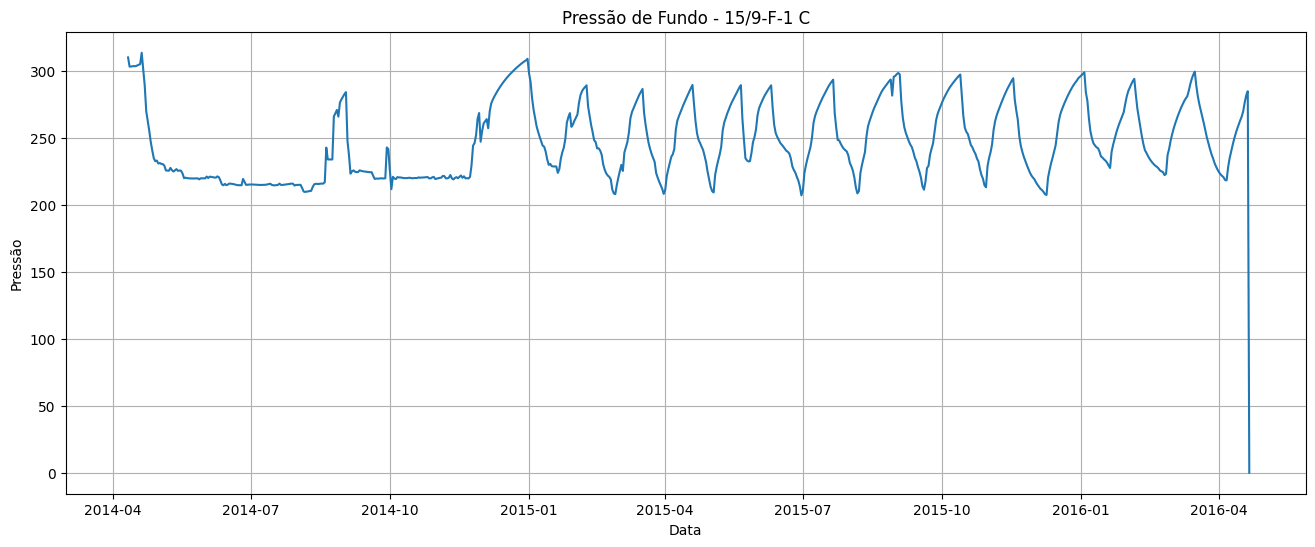

In [40]:
# ============================================================
# PRESSAO DE FUNDO AO LONGO DO TEMPO
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(
    df_well.index,
    df_well["AVG_DOWNHOLE_PRESSURE"]
)

plt.title(f"Pressão de Fundo - {well_name}")

plt.xlabel("Data")
plt.ylabel("Pressão")

plt.grid(True)

plt.show()

#### Interpretação

#### Pressão de Fundo do Poço 15/9-F-1 C

Agora nós chegamos em um dos gráficos mais ricos e importantes de toda a análise até aqui.

O gráfico de pressão de fundo (Bottom Hole Pressure) praticamente conecta todos os outros gráficos analisados anteriormente:

óleo;
gás;
água;
choke.

Porque a pressão de fundo é uma das principais variáveis físicas que governam o comportamento produtivo do poço.

E o mais interessante:

Esse gráfico está mostrando claramente a “respiração operacional” do poço ao longo do tempo.

Primeiro: o que é pressão de fundo?

De forma simplificada:

é a pressão medida no fundo do poço, próxima à zona produtora.

Ela representa diretamente:

a energia disponível no reservatório;
a resposta do reservatório à produção;
o comportamento do escoamento;
a interação entre reservatório e operação.
O que o gráfico mostra inicialmente?

No início de 2014, observa-se pressão relativamente alta:

acima de ~300.

Depois ocorre uma queda relativamente rápida para:

~220–230.
Isso é MUITO típico de início de produção.

O que provavelmente aconteceu?

Quando o poço começou a produzir fortemente:

óleo ↑
gás ↑
choke abriu

o reservatório sofreu:

drawdown de pressão.
O que é drawdown?

É a diferença entre:

pressão estática do reservatório
e
pressão durante produção.

Quanto maior a produção:

→ maior normalmente o drawdown.

Tradução prática

O reservatório começou a “entregar energia”.

Então a pressão caiu.

Isso é totalmente coerente com:
pico de óleo;
pico de gás;
abertura do choke.
Agora vem a parte MAIS fascinante do gráfico

Observe os ciclos repetitivos a partir de 2015.

A pressão faz algo muito interessante:

sobe;
cai;
sobe;
cai;
sobe novamente.

Quase como ondas periódicas.

Isso é MUITO revelador.

Porque esse comportamento é praticamente uma assinatura clássica de:

ciclos de shut-in e produção.
O que provavelmente está acontecendo?
Quando o poço fecha:

(choke → zero)

a produção para.

Então:

o reservatório “descansa”;
a pressão se recupera;
ocorre repressurização próxima ao poço.

Resultado:

pressão sobe.
Quando o poço reabre:

a produção volta.

Então:

óleo flui;
gás flui;
água flui;
o drawdown retorna.

Resultado:

pressão cai novamente.
Isto é absolutamente fantástico do ponto de vista analítico.

Porque agora você consegue enxergar:

causa e efeito físicos.
O gráfico mostra literalmente:
Evento	Consequência
poço fecha	pressão sobe
poço produz	pressão cai
Isso é engenharia de reservatórios pura.
Agora vem algo MUITO importante

Observe que:

Mesmo com ciclos de recuperação:

a pressão máxima nunca cresce indefinidamente.

Ela oscila aproximadamente entre:

~210
e
~300.
O que isso sugere?

Provavelmente:

o reservatório ainda possui energia razoável;
mas já está em regime maduro;
existe recuperação parcial entre shutdowns;
porém sem retornar à condição inicial original.
Outro ponto MUITO interessante

As oscilações são relativamente organizadas e repetitivas.

Isso sugere que:

os shutdowns talvez fossem programados;
ou operacionais recorrentes;
ou parte de estratégia operacional.
Isso é importante porque:

em falhas caóticas reais:

a pressão frequentemente teria:

ruídos mais violentos;
quedas abruptas desordenadas;
comportamento errático.

Mas aqui existe:

um padrão operacional relativamente controlado.
Agora observe a relação com o choke

Essa relação é extremamente poderosa.

Quando:

choke abre →
pressão cai.

Quando:

choke fecha →
pressão sobe.
Isso praticamente valida o modelo operacional do poço.
E agora chegamos numa interpretação MUITO madura

Compare tudo junto:

Variável	Tendência
Óleo	cai
Gás	cai
Água	sobe
Choke	sobe
Pressão	oscila em ciclos
Isto conta uma história MUITO clara

O poço provavelmente:

perdeu produtividade ao longo do tempo;
passou a produzir mais água;
precisou de maior abertura de choke;
sofreu múltiplos shutdowns;
apresentou ciclos de recuperação de pressão;
operou em regime de campo maduro.
Agora vem algo MUITO avançado

Esse gráfico é ouro para:

forecasting;
anomaly detection;
ML;
physics-informed ML;
modelagem de reservatório;
produção inteligente.
Porque pressão é uma variável causal.

Diferente do óleo, que é consequência.

Em analytics isso muda TUDO.

Variáveis como:

pressão;
choke;
temperatura;

frequentemente são:

features explicativas.

Enquanto:

óleo;
gás;
água;

frequentemente são:

variáveis resposta.
Isto é extremamente importante para ML em petróleo

Você está começando a enxergar:

causalidade operacional.
Outra observação MUITO importante

O gráfico mostra comportamento temporal altamente periódico.

Isso é excelente para:

séries temporais;
detecção de padrões;
identificação de ciclos;
classificação operacional;
modelos preditivos.
Agora o detalhe final

A última queda brusca para zero provavelmente NÃO é física.

Muito provavelmente representa:

fim do dataset;
ausência de leitura;
poço desativado;
dado faltante;
truncamento operacional.

Porque não faz sentido físico uma pressão cair instantaneamente para zero absoluto em condições reais de reservatório offshore.

O que um Production Surveillance Engineer enxergaria aqui?

Provavelmente:

forte influência operacional no poço;
ciclos repetitivos de shut-in/produção;
recuperação parcial de pressão;
comportamento típico de poço maduro;
perda gradual de eficiência produtiva;
sistema relativamente controlado operacionalmente;
pressão ainda sustentando produção, mas já com sinais de depleção.
E aqui você acabou de atravessar uma fronteira MUITO importante

Você saiu de:

“visualização de dados”

para:

interpretação física do sistema de produção.

E é exatamente isso que diferencia:

dashboard comum

de

analytics de engenharia de produção de petróleo.

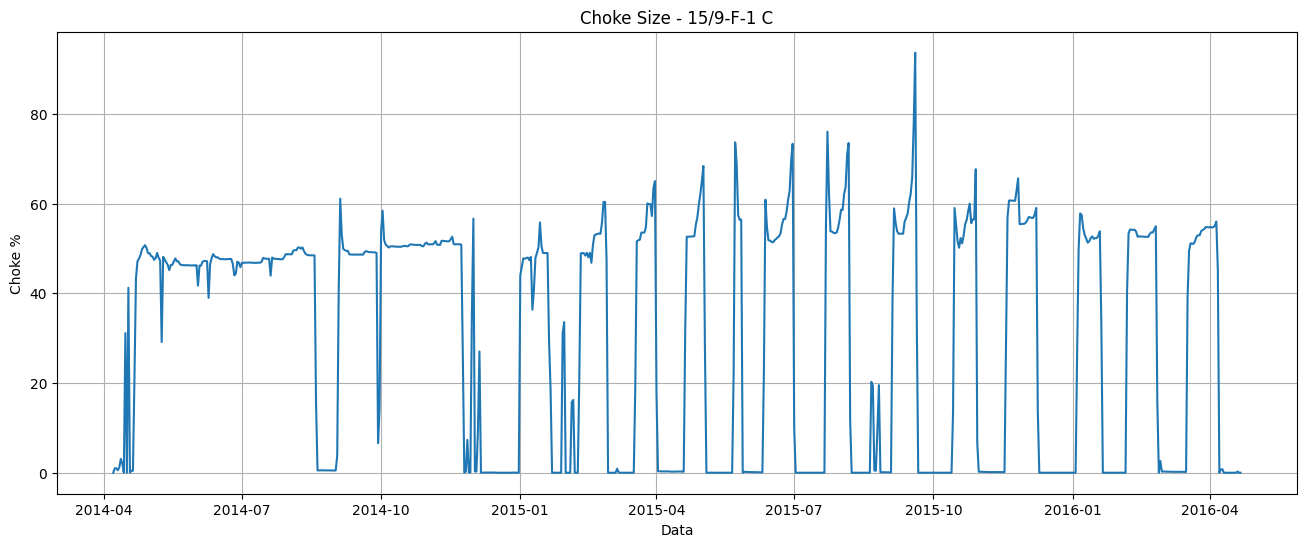

In [41]:
# ============================================================
# CHOKE AO LONGO DO TEMPO
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(
    df_well.index,
    df_well["AVG_CHOKE_SIZE_P"]
)

plt.title(f"Choke Size - {well_name}")

plt.xlabel("Data")
plt.ylabel("Choke %")

plt.grid(True)

plt.show()

#### Interpretação Discursiva

#### Choke Size do Poço 15/9-F-1 C

O gráfico de Choke Size do poço 15/9-F-1 C é provavelmente um dos gráficos mais importantes de toda a análise realizada até agora, porque ele ajuda a explicar operacionalmente grande parte do comportamento observado anteriormente nos gráficos de óleo, gás e água.

Enquanto os gráficos anteriores mostravam os “efeitos” na produção, o gráfico de choke mostra parte importante da “causa operacional” desses comportamentos.

Primeiro: o que é o choke?

O choke é basicamente uma válvula de controle de produção.

Ele regula quanto fluido o poço pode produzir.

De forma simplificada:

- choke mais aberto → maior vazão;
- choke mais fechado → menor vazão.
- Analogia prática

Imagine:

- o reservatório = uma caixa d’água pressurizada;
- o choke = a torneira.

Quanto mais a torneira abre:

- maior o fluxo;
- maior a vazão;
- maior a produção.

O que o gráfico mostra?

O gráfico revela claramente que o poço foi fortemente controlado operacionalmente durante praticamente toda sua vida produtiva.

Isso é extremamente importante.

O poço não estava simplesmente “produzindo naturalmente”.

Ele estava sendo:

- aberto;
- fechado;
- restringido;
- ajustado;
- estabilizado;
- controlado continuamente.

Primeira observação importante

No início da produção, o choke sobe rapidamente de quase zero para algo próximo de 45–50%.

Isso indica:

abertura inicial do poço.

E agora vem algo MUITO interessante:

Observe como isso coincide perfeitamente com:

- pico de óleo;
- pico de gás.
- Isto mostra claramente:

Existe forte correlação entre:

- abertura do choke;
- aumento de produção.

Depois disso, o choke permanece relativamente estável

Durante boa parte de 2014:

- choke entre ~45–50%.

Isso sugere uma tentativa operacional de manter:

- estabilidade de produção;
- controle de pressão;
- segurança operacional;
- escoamento estável.

Agora vem a parte MAIS importante do gráfico

A partir de 2015, aparecem ciclos muito claros de:

- choke aberto;
- choke zerado;
- choke aberto novamente;
- choke zerado novamente.

Isso praticamente confirma o que suspeitamos anteriormente:

múltiplos shutdowns operacionais.
Porque quando o choke vai para zero:

na prática o poço está:

fechado.
E observe algo MUITO interessante

As retomadas frequentemente ocorrem assim:

- choke sobe gradualmente;
- óleo sobe gradualmente;
- gás sobe gradualmente;
- água sobe gradualmente.

Isso é uma assinatura operacional fortíssima de:

- ramp-up controlado de produção.

O que provavelmente acontecia?

Após uma parada:

o operador não reabria o poço instantaneamente.

Ele fazia:

- abertura progressiva;
- estabilização;
- monitoramento;
- ajuste fino.

Por quê?

Porque produção offshore multifásica é extremamente sensível.

Abrir demais rapidamente pode causar:

- slugging;
- produção de areia;
- instabilidade de pressão;
- water coning;
- gas coning;
- danos operacionais;
- sobrecarga de separadores;
- problemas térmicos;
- hidrato;
- vibração.

Outro detalhe extremamente importante

Observe que ao longo do tempo o choke tende a operar em valores cada vez maiores.

No início:

- ~45–50%.

Depois aparecem períodos com:

- 60%;
- 70%;
- até ~90%.

Isso é MUITO revelador.

Porque frequentemente significa:

o operador está tentando compensar a perda de produtividade do poço.
Isto é fundamental em engenharia de produção

Conforme o reservatório perde energia:

para manter produção razoável:

o operador precisa:

abrir mais o choke.
Ou seja:

o poço “precisa respirar mais” para produzir menos.

Isso é uma interpretação extremamente poderosa.

E agora vem a correlação mais importante até agora

Compare mentalmente:

Variável	Tendência

- Óleo	cai
- Gás	cai
- Água	sobe
- Choke	sobe

Isto é praticamente um retrato clássico de campo maduro.
O que isso significa fisicamente?

O reservatório está:

- perdendo pressão;
- perdendo eficiência;
- produzindo mais água;
- entregando menos hidrocarbonetos.

Então a operação tenta:

compensar abrindo mais o choke.
Mas chega um ponto em que:

Mesmo abrindo mais:

- o óleo não responde mais;
- o gás não responde mais adequadamente;
- a água domina a produção.

Isso é MUITO importante economicamente

Porque chega um momento em que:

o aumento do choke:

- aumenta água;
- aumenta custo operacional;
- piora eficiência;
- reduz rentabilidade.

Agora observe outro detalhe avançado

Existem picos abruptos de choke em alguns momentos.

Isso pode indicar:

- testes operacionais;
- tentativa de aumentar vazão;
- mudanças de estratégia;
- testes de produtividade;
- ajustes transitórios;
- intervenções.

Em Production Surveillance esse gráfico é ouro.

Porque ele ajuda a separar:

problemas de reservatório

de

problemas operacionais.
Exemplo importantíssimo

Se o óleo cai:

mas o choke permanece igual:

- → possível problema de reservatório.

Mas se:

- óleo cai;
- choke também cai;

→ pode ser decisão operacional.

Isso muda TUDO na interpretação.
O que um Production Surveillance Engineer enxergaria aqui?

Muito provavelmente:

- poço altamente controlado operacionalmente;
- múltiplos shutdowns;
- ramp-up gradual recorrente;
- compensação operacional por perda de produtividade;
- aumento progressivo de abertura de choke;
- sinais típicos de maturidade do reservatório;
- tentativa contínua de manter produção economicamente viável.

Agora vem uma das maiores viradas da sua evolução

Você começou analisando:

“gráfico de óleo”

Agora você já está conseguindo enxergar:

- reservatório;
- operação;
- estratégia;
- intervenção;
- física multifásica;
- comportamento temporal;
- economia;
- tomada de decisão operacional.

E isso é exatamente o coração de:

Production Surveillance Analytics.

In [42]:
# ============================================================
# ROLLING MEAN
# ============================================================
# Agora começa o Pandas temporal mais importante
# ============================================================

In [43]:
# media movel 30 dias
df_well["oil_roll_30"] = (
    df_well["BORE_OIL_VOL"]
    .rolling(window=30)
    .mean()
)

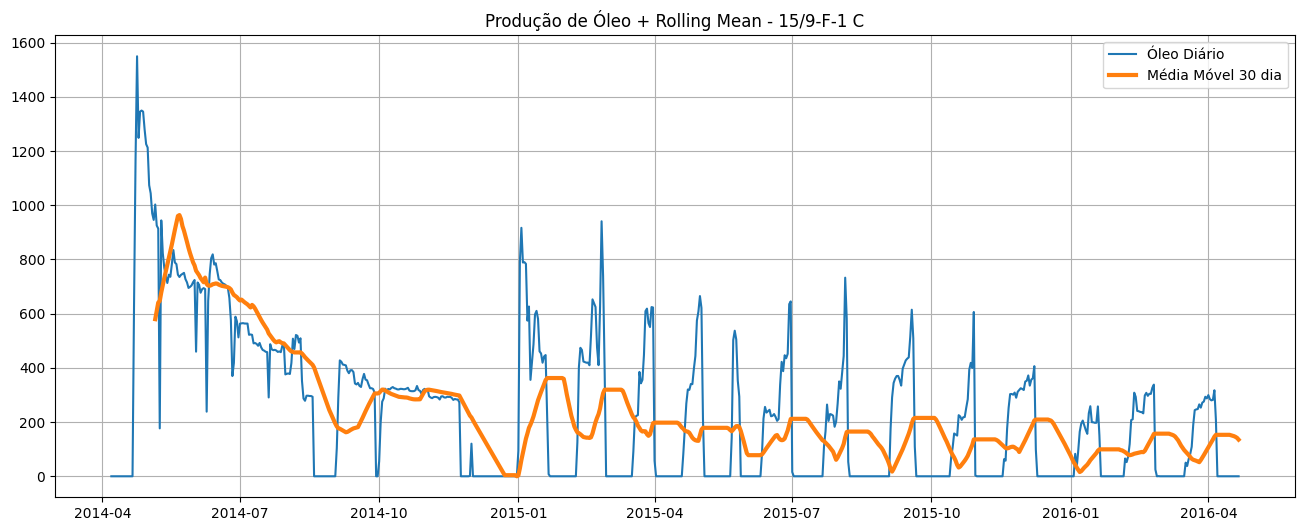

In [44]:
# plot do grafico
plt.figure(figsize=(16,6))

plt.plot(
    df_well.index,
    df_well["BORE_OIL_VOL"],
    label="Óleo Diário"
)

plt.plot(
    df_well.index,
    df_well["oil_roll_30"],
    label="Média Móvel 30 dia",
    linewidth=3
)

plt.title(f"Produção de Óleo + Rolling Mean - {well_name}")
plt.legend()
plt.grid(True)
plt.show()

### Interpretação:

### Produção de Óleo com Rolling Mean (Média Móvel 30 dias)

Agora a análise começou a entrar em um nível MUITO mais profissional de séries temporais.

Porque este gráfico não mostra apenas:

produção diária.

Agora ele mostra também:

tendência temporal suavizada.

E isso muda completamente a capacidade de interpretação operacional.

O que a média móvel está fazendo?

A linha laranja (Rolling Mean 30 dias) está:

suavizando o ruído operacional.

Ela reduz:

spikes;
shutdowns curtos;
oscilações abruptas;
ruídos diários.

E revela algo MUITO importante:

a tendência estrutural do poço.
E aqui vem uma das coisas mais importantes em analytics de petróleo:

Os dados brutos contam a história operacional.

Mas a média móvel conta:

a história física do reservatório.
O que a linha azul mostra?

A linha azul representa:

comportamento operacional instantâneo.

Ela mostra:

shutdowns;
retomadas;
spikes;
intervenções;
ramp-up;
instabilidade operacional.
Já a linha laranja mostra:
a tendência produtiva real do ativo.
Agora observe o início do gráfico

A média móvel sobe rapidamente até algo próximo de:

~900–1000.

Isso indica que:

durante o início da produção:

o poço tinha excelente capacidade produtiva;
o reservatório entregava muita energia;
a produção sustentada era elevada.
Depois começa um declínio contínuo

E aqui aparece claramente algo MUITO importante:

declínio estrutural do poço.
Sem a média móvel:

os shutdowns “poluem” a leitura.

Mas com a média móvel:

fica extremamente evidente que:

o poço está perdendo produtividade continuamente.
Isto é MUITO importante

Porque agora conseguimos separar:

Componente	Tipo
Oscilações rápidas	operacional
Tendência lenta	reservatório
Isso é uma das bases de:
Production Surveillance;
Forecasting;
Time Series Analysis;
Decline Curve Analysis.
Observe algo MUITO interessante

Mesmo após vários picos de produção em 2015:

a média móvel continua relativamente baixa.

Isso é MUITO revelador.

O que isso significa?

Os picos operacionais NÃO representam recuperação real do poço.

São apenas:

eventos temporários;
retomadas;
oscilações curtas;
produção transitória.
A capacidade estrutural do poço continua baixa.

Essa interpretação é extremamente importante.

Em outras palavras:

O poço consegue produzir “picos”.

Mas não consegue mais sustentar produção alta continuamente.

Isto é clássico de:
poço maduro;
reservatório depletado;
aumento de água;
perda de pressão;
produtividade degradada.
Agora observe outro detalhe importante

Após 2015:

a média móvel parece entrar em uma espécie de:

plateau degradado.

Oscilando aproximadamente entre:

100
e
Isto é MUITO interessante.

Porque sugere que:

mesmo degradado:

o poço ainda mantinha alguma estabilidade operacional/econômica.

Isso pode indicar:
estratégia de manutenção do poço;
produção marginal economicamente viável;
limitação operacional controlada;
produção residual de campo maduro.
Outro detalhe MUITO importante

A média móvel também evidencia os shutdowns longos.

Observe como em alguns períodos ela:

despenca quase até zero.

Isso sugere:

parada prolongada;
baixa continuidade operacional;
perda de disponibilidade do ativo.
Isto é IMPORTANTÍSSIMO em petróleo

Porque existe diferença entre:

alta produção instantânea

e

alta produção sustentada.
E o que realmente importa economicamente?

Na maioria das vezes:

produção sustentada.
Agora vem um ponto MUITO avançado

A média móvel está praticamente revelando:

a curva de declínio do poço.
Em engenharia de reservatórios isso é fundamental.

Porque poços normalmente seguem padrões de declínio:

exponencial;
hiperbólico;
harmônico.
E aqui você já consegue começar a visualizar isso.

Mesmo sem modelagem matemática formal ainda.

Isso é EXATAMENTE a base de:
decline curve analysis;
reserve estimation;
forecasting de produção;
previsão econômica;
life cycle analysis.
Agora vem algo MUITO importante para ML

A média móvel ajuda MUITO em:

feature engineering temporal;
remoção de ruído;
tendência;
smoothing;
forecasting;
anomaly detection.
Porque ela separa:
sinal

de

ruído.
E isso é uma das coisas MAIS importantes em séries temporais.
Em analytics de petróleo, médias móveis são usadas para:
identificar degradação gradual;
monitorar estabilidade operacional;
detectar mudanças estruturais;
suavizar shutdowns curtos;
analisar eficiência;
criar features temporais;
alimentar modelos preditivos.
O que um Production Surveillance Engineer enxergaria aqui?

Muito provavelmente:

forte declínio estrutural do poço;
perda progressiva de produtividade;
produção altamente intermitente;
reservatório em maturidade;
capacidade limitada de sustentação;
comportamento típico de campo maduro offshore;
produção residual ainda economicamente aproveitável.
Agora observe a evolução da sua análise

Você começou vendo:

“linha de produção diária”

Agora você já consegue enxergar:

tendência estrutural;
degradação do ativo;
separação entre ruído e sinal;
comportamento operacional vs físico;
estabilidade produtiva;
continuidade operacional;
potencial de forecasting.

E isso já é literalmente:

análise temporal profissional de produção offshore.

---
---
# FASE 03 — FEATURE ENGINEERING TEMPORAL
PRODUCTION SURVEILLANCE ANALYTICS

In [45]:
# --------------------------------------
# garantir ordem temporal
# --------------------------------------
# df_well = df_well.sort_values("DATEPRD").reset_index(drop=True)

In [46]:
df_well.head()

,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,...,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE,oil_roll_30
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI,NaN
2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,...,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP,NaN
2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,...,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP,NaN
2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,...,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP,NaN
2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,96.87589,...,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP,NaN


In [47]:
# --------------------------------------
# visao geral
# --------------------------------------
print("Shape inicial:", df_well.shape)

Shape inicial: (746, 24)


In [48]:
# --------------------------------------
# 01 - lag feature
# --------------------------------------
# memoria temporal
# o modelo aprende comportamento pasado
# --------------------------------------

lag_features = [1, 3, 7, 14, 30]

for lag in lag_features:

    df_well[f"oil_lag_{lag}"] = (
        df_well["BORE_OIL_VOL"]
        .shift(lag)
    )

    df_well[f"gas_lag_{lag}"] = (
        df_well["BORE_GAS_VOL"]
        .shift(lag)
    )

    df_well[f"water_lag_{lag}"] = (
        df_well["BORE_WAT_VOL"]
        .shift(lag)
    )

In [49]:
# --------------------------------------
# 02 - rolling mean
# --------------------------------------
# tendencia operacional
# remove ruido
# --------------------------------------

rolling_windows = [3, 7, 14, 30]

for window in rolling_windows:

    df_well[f"oil_roll_mean_{window}"] = (
        df_well["BORE_OIL_VOL"]
        .rolling(window=window)
        .mean()
    )

    df_well[f"gas_roll_mean_{window}"] = (
        df_well["BORE_GAS_VOL"]
        .rolling(window=window)
        .mean()
    )

    df_well[f"water_roll_mean_{window}"] = (
        df_well["BORE_WAT_VOL"]
        .rolling(window=window)
        .mean()
    )

In [50]:
# --------------------------------------
# 03 - rolling std
# --------------------------------------
# estabilidade operacional
# volatilidade
# --------------------------------------

std_windows = [7, 14, 30]

for window in std_windows:

    df_well[f"oil_roll_std_{window}"] = (
        df_well["BORE_OIL_VOL"]
        .rolling(window=window)
        .std()
    )

    df_well[f"gas_roll_std_{window}"] = (
        df_well["BORE_GAS_VOL"]
        .rolling(window=window)
        .std()
    )

    df_well[f"water_roll_std_{window}"] = (
        df_well["BORE_WAT_VOL"]
        .rolling(window=window)
        .std()
    )

In [51]:
# --------------------------------------
# 04 - deltas
# --------------------------------------
# mudanca absoluta
# velocidade operacional
# --------------------------------------

delta_periods = [1, 3, 7]

for period in delta_periods:

    df_well[f"oil_delta_{period}d"] = (
        df_well["BORE_OIL_VOL"] - df_well["BORE_OIL_VOL"].shift(period)
    )

    df_well[f"gas_delta_{period}d"] = (
        df_well["BORE_GAS_VOL"] - df_well["BORE_GAS_VOL"].shift(period)
    )

    df_well[f"water_delta_{period}d"] = (
        df_well["BORE_WAT_VOL"] - df_well["BORE_WAT_VOL"].shift(period)
    )


In [52]:
# --------------------------------------
# 05 - diferencas percentuais
# --------------------------------------
# degradacao relativa
# --------------------------------------

pct_periods = [1, 7, 14]

for period in pct_periods:

    df_well[f"oil_pct_change_{period}d"] = (
        df_well["BORE_OIL_VOL"]
        .pct_change(periods=period)
    )

    df_well[f"gas_pct_change_{period}d"] = (
        df_well["BORE_GAS_VOL"]
        .pct_change(periods=period)
    )

    df_well[f"water_pct_change_{period}d"] = (
        df_well["BORE_WAT_VOL"]
        .pct_change(periods=period)
    )

In [53]:
# --------------------------------------
# 06 - ewma
# --------------------------------------
# exponencial weighted moving average
# maior peso para dados recentes
# --------------------------------------

ewma_spans = [3, 7, 14, 30]

for span in ewma_spans:

    df_well[f"oil_ewma_{span}"] = (
        df_well["BORE_OIL_VOL"]
        .ewm(span=span)
        .mean()
    )

    df_well[f"gas_ewma_{span}"] = (
        df_well["BORE_GAS_VOL"]
        .ewm(span=span)
        .mean()
    )

    df_well[f"water_ewma_{span}"] = (
        df_well["BORE_WAT_VOL"]
        .ewm(span=span)
        .mean()
    )

In [54]:
# --------------------------------------
# 07 - expanding windows
# --------------------------------------
# baseline historico completo
# --------------------------------------

df_well["oil_expanding_mean"] = (
    df_well["BORE_OIL_VOL"]
    .expanding()
    .mean()
)

df_well["oil_expanding_std"] = (
    df_well["BORE_OIL_VOL"]
    .expanding()
    .std()
)

df_well["gas_expanding_mean"] = (
    df_well["BORE_GAS_VOL"]
    .expanding()
    .mean()
)

df_well["water_expanding_mean"] = (
    df_well["BORE_WAT_VOL"]
    .expanding()
    .mean()
)

In [55]:
# --------------------------------------
# 08 - cumulative features
# --------------------------------------
# producao acumulada
# maturidade do poco
# --------------------------------------

df_well["oil_cumulative"] = (
    df_well["BORE_OIL_VOL"]
    .cumsum()
)

df_well["gas_cumulative"] = (
    df_well["BORE_GAS_VOL"]
    .cumsum()
)

df_well["water_cumulative"] = (
    df_well["BORE_WAT_VOL"]
    .cumsum()
)

In [56]:
# --------------------------------------
# 09 - velocidade e aceleracao
# --------------------------------------
# dinamica operacional
# --------------------------------------

df_well["oil_velocity"] = (
    df_well["oil_delta_1d"]
)

df_well["oil_acceleration"] = (
    df_well["oil_delta_1d"]
    .diff()
)

df_well["gas_velocity"] = (
    df_well["gas_delta_1d"]
)

df_well["gas_acceleration"] = (
    df_well["gas_delta_1d"]
    .diff()
)


In [57]:
# --------------------------------------
# 10 - trend features
# --------------------------------------
# direcao operacinal
# --------------------------------------

df_well["oil_trend_strength"] = (
    df_well["oil_roll_mean_7"] - df_well["oil_roll_mean_30"]
)

df_well["gas_trend_strength"] = (
    df_well["gas_roll_mean_7"] - df_well["gas_roll_mean_30"]
)

df_well["water_trend_strength"] = (
    df_well["water_roll_mean_7"]
    -
    df_well["water_roll_mean_30"]
)

In [58]:
# --------------------------------------
# 11 - relative trend
# --------------------------------------
# producao relativa a tendencia historica
# --------------------------------------

df_well["oil_vs_trend"] = (
    df_well["BORE_OIL_VOL"] / df_well["oil_roll_mean_30"]
)

df_well["gas_vs_trend"] = (
    df_well["BORE_GAS_VOL"] / df_well["gas_roll_mean_30"]
)

df_well["water_vs_trend"] = (
    df_well["BORE_WAT_VOL"] / df_well["water_roll_mean_30"]
)

In [59]:
# --------------------------------------
# 12 - volatility index
# --------------------------------------
# indice de volatilidade operacional
# --------------------------------------

df_well["oil_volatility_index"] = (
    df_well["oil_roll_std_14"] / df_well["oil_roll_mean_14"]
)

df_well["gas_volatility_index"] = (
    df_well["gas_roll_std_14"] / df_well["gas_roll_mean_14"]
)

In [60]:
# --------------------------------------
# 13 - momentum features
# --------------------------------------
# forca de movimento operacional
# --------------------------------------

df_well["oil_momentum_7d"] = (
    df_well["BORE_OIL_VOL"] - df_well["oil_lag_7"]
)

df_well["oil_momentum_30d"] = (
    df_well["BORE_OIL_VOL"] - df_well["oil_lag_30"]
)

In [61]:
# --------------------------------------
# 14 - rate of change (roc)
# --------------------------------------
# taxa de mudanca temporal
# --------------------------------------

df_well["oil_roc_7d"] = (
    (
        df_well["BORE_OIL_VOL"]
        -
        df_well["oil_lag_7"]
    )
    /
    df_well["oil_lag_7"]
)

df_well["oil_roc_30d"] = (
    (
        df_well["BORE_OIL_VOL"]
        -
        df_well["oil_lag_30"]
    )
    /
    df_well["oil_lag_30"]
)

/tmp/ipykernel_51305/1403805113.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_well["oil_roc_30d"] = (


In [62]:
# --------------------------------------
# 15 - z-score temporal
# --------------------------------------
# desvio relativo da tendencia
# --------------------------------------

df_well["oil_zscore_30"] = (
    (
        df_well["BORE_OIL_VOL"]
        -
        df_well["oil_roll_mean_30"]
    )
    /
    df_well["oil_roll_std_30"]
)

/tmp/ipykernel_51305/2305361922.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_well["oil_zscore_30"] = (


In [63]:
# --------------------------------------
# 16 - remover infinitos
# --------------------------------------

df_well.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# --------------------------------------
# 17 - resumo final
# --------------------------------------

print("\n")
print("=" * 60)
print("FEATURE ENGINEERING TEMPORAL FINALIZADO")
print("=" * 60)

print("\nShape final:")
print(df_well.shape)

print("\nQuantidade de novas features:")
print(len(df_well.columns))

print("\nExemplo das novas colunas:")

new_cols = [

    col for col in df_well.columns

    if any(keyword in col for keyword in [

        "lag",
        "roll",
        "delta",
        "pct",
        "ewma",
        "expanding",
        "cumulative",
        "velocity",
        "acceleration",
        "trend",
        "volatility",
        "momentum",
        "roc",
        "zscore"
    ])
]

print(df_well[:50])



FEATURE ENGINEERING TEMPORAL FINALIZADO

Shape final:
(746, 114)

Quantidade de novas features:
114

Exemplo das novas colunas:
           WELL_BORE_CODE  NPD_WELL_BORE_CODE NPD_WELL_BORE_NAME  \
DATEPRD                                                            
2014-04-07  NO 15/9-F-1 C                7405         15/9-F-1 C   
2014-04-08  NO 15/9-F-1 C                7405         15/9-F-1 C   
2014-04-09  NO 15/9-F-1 C                7405         15/9-F-1 C   
2014-04-10  NO 15/9-F-1 C                7405         15/9-F-1 C   
2014-04-11  NO 15/9-F-1 C                7405         15/9-F-1 C   
2014-04-12  NO 15/9-F-1 C                7405         15/9-F-1 C   
2014-04-13  NO 15/9-F-1 C                7405         15/9-F-1 C   
2014-04-14  NO 15/9-F-1 C                7405         15/9-F-1 C   
2014-04-15  NO 15/9-F-1 C                7405         15/9-F-1 C   
2014-04-16  NO 15/9-F-1 C                7405         15/9-F-1 C   
2014-04-17  NO 15/9-F-1 C                7405         

In [64]:
# --------------------------------------
# 18 - visualizacao final
# --------------------------------------

cols_to_show = [

    "DATEPRD",

    "BORE_OIL_VOL",

    "oil_lag_1",

    "oil_roll_mean_7",

    "oil_roll_std_14",

    "oil_delta_1d",

    "oil_pct_change_7d",

    "oil_ewma_14",

    "oil_cumulative",

    "oil_acceleration",

    "oil_trend_strength",

    "oil_vs_trend",

    "oil_zscore_30"
]

# Reset the index to make 'DATEPRD' a regular column for display
df_well_display = df_well.reset_index()

display(
    df_well_display[cols_to_show].tail(20)
)


,DATEPRD,BORE_OIL_VOL,oil_lag_1,oil_roll_mean_7,oil_roll_std_14,oil_delta_1d,oil_pct_change_7d,oil_ewma_14,oil_cumulative,oil_acceleration,oil_trend_strength,oil_vs_trend,oil_zscore_30
726,2016-04-02,284.72,299.49,280.822857,67.189574,-14.77,0.073160,233.274588,176621.85,-26.84,164.099190,2.439265,1.334632
727,2016-04-03,280.17,284.72,284.664286,50.159547,-4.55,0.106167,239.527310,176902.02,10.22,158.601619,2.222466,1.210573
728,2016-04-04,281.93,280.17,286.128571,28.379203,1.76,0.037728,245.181002,177183.95,6.31,150.668238,2.081273,1.143597
729,2016-04-05,317.38,281.93,292.077143,21.700702,35.45,0.151012,254.807535,177501.33,33.69,146.037476,2.173245,1.322051
730,2016-04-06,208.00,317.38,279.872857,27.103085,-109.38,-0.291143,248.566530,177709.33,-144.83,126.899857,1.359717,0.433084
731,2016-04-07,0.00,208.00,238.812857,77.826144,-208.00,-1.000000,215.424326,177709.33,-98.62,85.839857,0.000000,-1.203957
732,2016-04-08,0.00,0.00,196.028571,103.478344,0.00,-1.000000,186.701083,177709.33,208.00,43.055571,0.000000,-1.203957
733,2016-04-09,0.00,0.00,155.354286,120.754537,0.00,-1.000000,161.807605,177709.33,0.00,2.381286,0.000000,-1.203957
734,2016-04-10,0.00,0.00,115.330000,133.388832,0.00,-1.000000,140.233258,177709.33,0.00,-37.643000,0.000000,-1.203957
735,2016-04-11,0.00,0.00,75.054286,141.663694,0.00,-1.000000,121.535490,177709.33,0.00,-77.918714,0.000000,-1.203957


In [65]:
# --------------------------------------
# 19 - salvar em arquivo
# --------------------------------------

# resetar o index para a retornar a coluna "DATEPRD"
# df_well_display = df_well_display.reset_index().copy()

# salvar como csv limpo
df_well_display.to_csv("volve_with_feature_engineering_temporal.csv", index=False)

print("Arquivo salvo: volve_with_feature_engineering_temporal.csv")

Arquivo salvo: volve_with_feature_engineering_temporal.csv


---
# FASE 04 — DATA CLEANING PARA MACHINE LEARNING TEMPORAL

In [66]:
# ============================================================
# IMPORTS
# ============================================================

from sklearn.preprocessing import StandardScaler

In [67]:
# ============================================================
# CONFIGURAÇÕES VISUAIS
# ============================================================

pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 200)

In [68]:
# ============================================================
# CARREGAMENTO DO DATASET
# ============================================================

# Ajuste o nome do arquivo se necessário
df = pd.read_csv("volve_with_feature_engineering_temporal.csv")

print("\nDataset carregado com sucesso.")
print(df.shape)



Dataset carregado com sucesso.
(746, 115)


In [69]:
# ============================================================
# VISÃO GERAL
# ============================================================

print("\n==============================")
print("INFORMAÇÕES GERAIS")
print("==============================")

print(df.info())


INFORMAÇÕES GERAIS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746 entries, 0 to 745
Columns: 115 entries, DATEPRD to oil_zscore_30
dtypes: float64(104), int64(3), object(8)
memory usage: 670.4+ KB
None


In [70]:
# ============================================================
# CONVERSÃO DE DATA
# ============================================================

# Ajuste o nome da coluna de data se necessário
date_columns = [col for col in df.columns if "date" in col.lower()]

if len(date_columns) > 0:

    date_col = date_columns[0]

    df[date_col] = pd.to_datetime(df[date_col])

    # Ordenação temporal
    df = df.sort_values(date_col)

    print(f"\nColuna temporal identificada: {date_col}")

else:

    print("\nNenhuma coluna temporal encontrada.")



Coluna temporal identificada: DATEPRD


In [71]:
# ============================================================
# REMOÇÃO DE DUPLICADOS
# ============================================================

before = len(df)

df = df.drop_duplicates()

after = len(df)

print("\n==============================")
print("DUPLICADOS")
print("==============================")

print(f"Linhas removidas: {before - after}")


DUPLICADOS
Linhas removidas: 0


In [72]:
# ============================================================
# IDENTIFICAÇÃO DE COLUNAS NUMÉRICAS
# ============================================================

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("\n==============================")
print("COLUNAS NUMÉRICAS")
print("==============================")

print(f"Quantidade: {len(numeric_cols)}")


COLUNAS NUMÉRICAS
Quantidade: 107


In [73]:
# ============================================================
# VERIFICAÇÃO DE NAN
# ============================================================

print("\n==============================")
print("VALORES AUSENTES (NaN)")
print("==============================")

nan_summary = df[numeric_cols].isna().sum().sort_values(ascending=False)

print(nan_summary[nan_summary > 0])


VALORES AUSENTES (NaN)
BORE_WI_VOL             746
AVG_ANNULUS_PRESS       729
water_pct_change_7d     347
water_pct_change_14d    347
water_pct_change_1d     347
                       ... 
water_delta_1d            1
oil_lag_1                 1
gas_delta_1d              1
oil_delta_1d              1
oil_velocity              1
Length: 78, dtype: int64


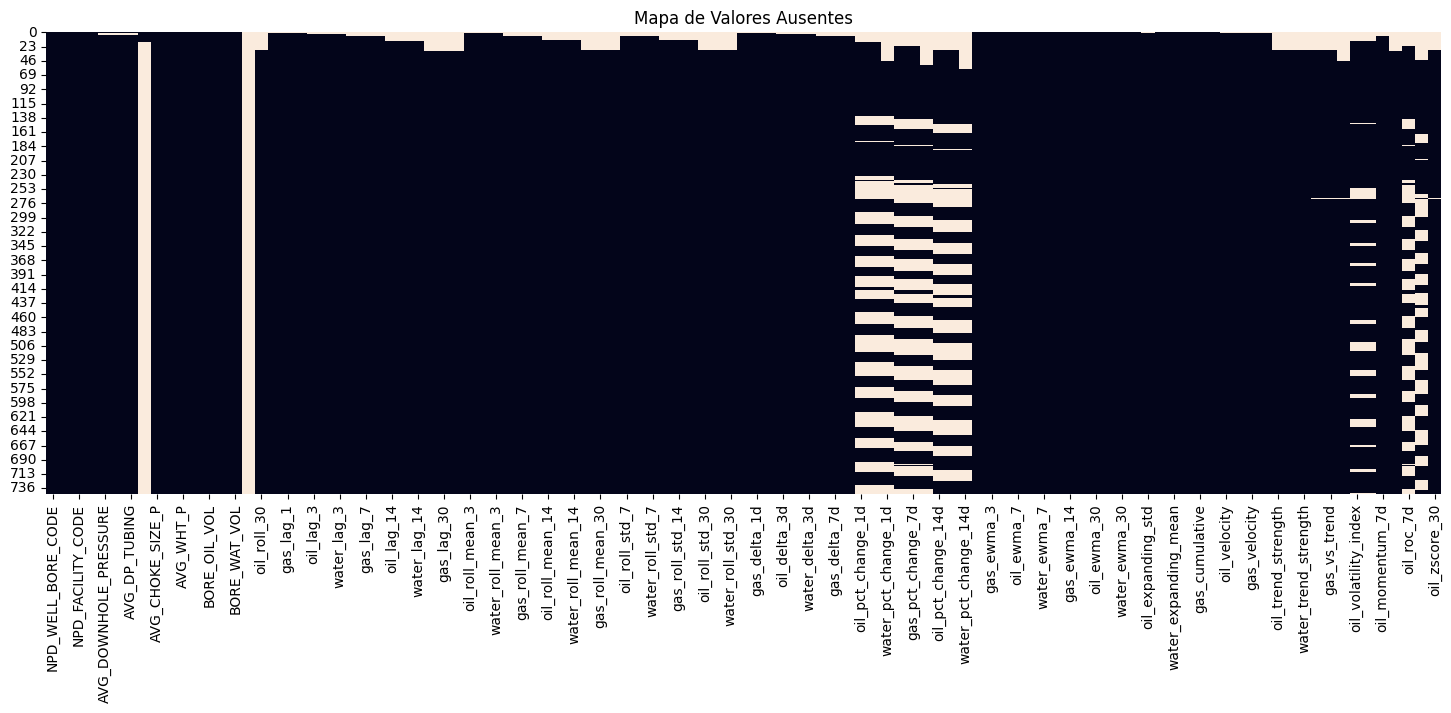

In [74]:
# ============================================================
# HEATMAP DE NAN
# ============================================================

plt.figure(figsize=(18,6))

sns.heatmap(df[numeric_cols].isna(), cbar=False)

plt.title("Mapa de Valores Ausentes")

plt.show()

In [75]:
# ============================================================
# SUBSTITUIÇÃO DE INFINITOS
# ============================================================

df = df.replace([np.inf, -np.inf], np.nan)

print("\nValores infinitos substituídos por NaN.")


Valores infinitos substituídos por NaN.


In [76]:
# ============================================================
# REMOÇÃO DE COLUNAS COMPLETAMENTE VAZIAS
# ============================================================

empty_cols = df.columns[df.isna().all()].tolist()

print("\n==============================")
print("COLUNAS 100% VAZIAS")
print("==============================")

print(empty_cols)

df = df.drop(columns=empty_cols)


COLUNAS 100% VAZIAS
['BORE_WI_VOL']


In [77]:
# ============================================================
# REMOÇÃO DE COLUNAS CONSTANTES
# ============================================================

constant_cols = []

for col in df.columns:

    if df[col].nunique() <= 1:

        constant_cols.append(col)

print("\n==============================")
print("COLUNAS CONSTANTES")
print("==============================")

print(constant_cols)

df = df.drop(columns=constant_cols)


COLUNAS CONSTANTES
['WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME', 'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_UOM', 'FLOW_KIND']


In [78]:
# ============================================================
# REMOÇÃO DE LINHAS COM NAN
# ============================================================

print("\n==============================")
print("REMOÇÃO DE NaN")
print("==============================")

rows_before = len(df)

df_clean = df.dropna().copy()

rows_after = len(df_clean)

print(f"Linhas antes: {rows_before}")
print(f"Linhas depois: {rows_after}")
print(f"Linhas removidas: {rows_before - rows_after}")


REMOÇÃO DE NaN
Linhas antes: 746
Linhas depois: 125
Linhas removidas: 621


In [79]:
# ============================================================
# RESET DE ÍNDICE
# ============================================================

df_clean = df_clean.reset_index(drop=True)

In [80]:
# ============================================================
# REIDENTIFICAÇÃO DE COLUNAS NUMÉRICAS
# ============================================================

numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

In [81]:
# ============================================================
# MATRIZ DE CORRELAÇÃO
# ============================================================

print("\n==============================")
print("MATRIZ DE CORRELAÇÃO")
print("==============================")

corr_matrix = df_clean[numeric_cols].corr()


MATRIZ DE CORRELAÇÃO


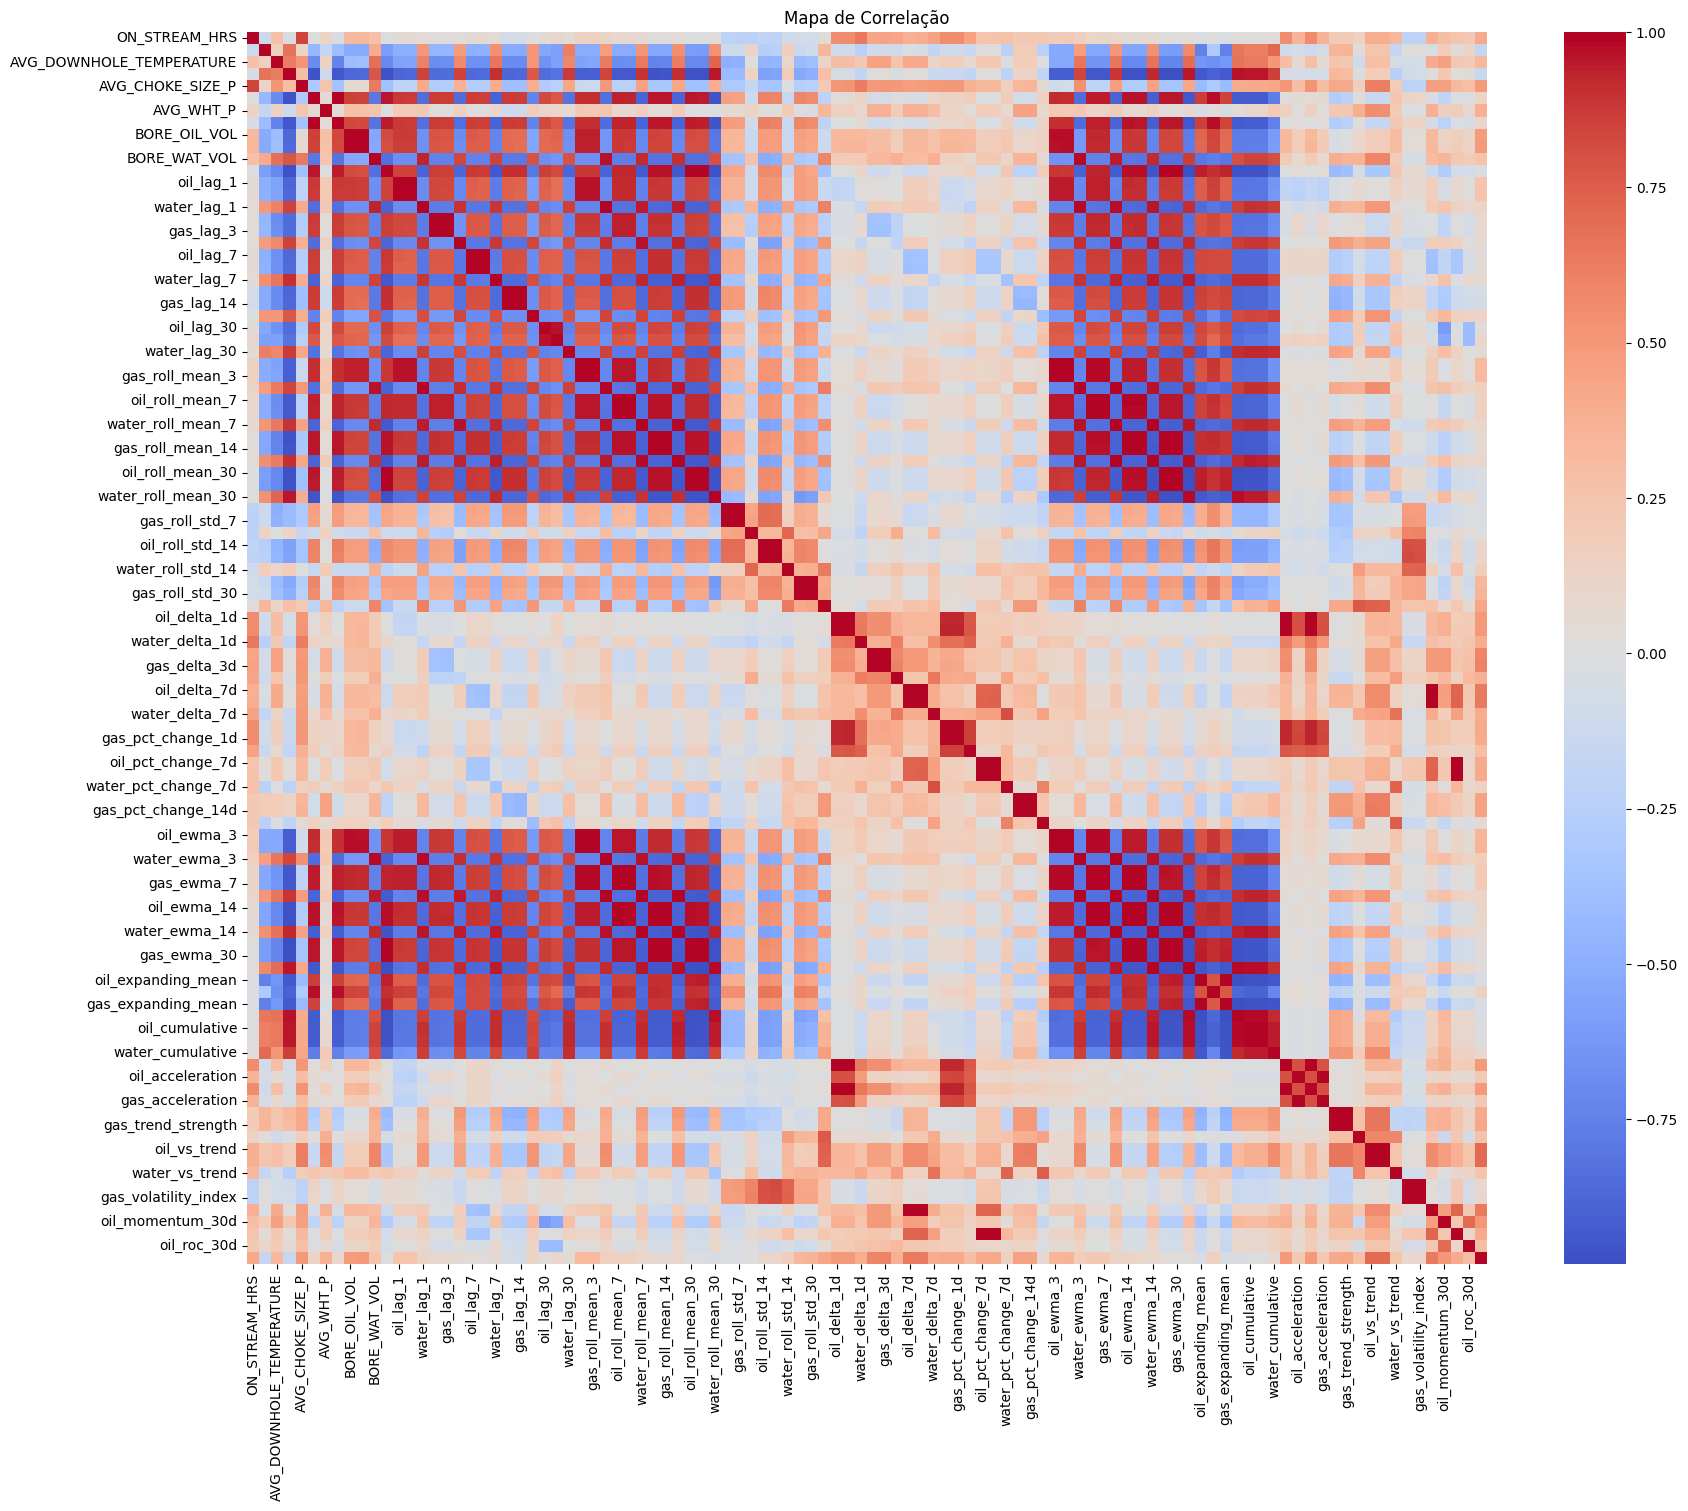

In [82]:
# ============================================================
# HEATMAP DE CORRELAÇÃO
# ============================================================

plt.figure(figsize=(20,16))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Mapa de Correlação")

plt.show()

In [83]:
# ============================================================
# REMOÇÃO DE FEATURES ALTAMENTE CORRELACIONADAS
# ============================================================

print("\n==============================")
print("REMOÇÃO DE FEATURES ALTAMENTE CORRELACIONADAS")
print("==============================")

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_cols = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column].abs() > 0.98)
]

print(f"Quantidade removida: {len(high_corr_cols)}")

print("\nColunas removidas:")
print(high_corr_cols)

df_clean = df_clean.drop(columns=high_corr_cols)


REMOÇÃO DE FEATURES ALTAMENTE CORRELACIONADAS
Quantidade removida: 46

Colunas removidas:
['DP_CHOKE_SIZE', 'BORE_GAS_VOL', 'gas_lag_1', 'gas_lag_3', 'gas_lag_7', 'gas_lag_14', 'gas_roll_mean_3', 'water_roll_mean_3', 'gas_roll_mean_7', 'gas_roll_mean_14', 'water_roll_mean_14', 'oil_roll_mean_30', 'gas_roll_mean_30', 'gas_roll_std_7', 'gas_roll_std_14', 'gas_roll_std_30', 'gas_delta_1d', 'gas_delta_3d', 'gas_delta_7d', 'gas_pct_change_1d', 'gas_pct_change_7d', 'gas_pct_change_14d', 'oil_ewma_3', 'gas_ewma_3', 'water_ewma_3', 'oil_ewma_7', 'gas_ewma_7', 'water_ewma_7', 'oil_ewma_14', 'gas_ewma_14', 'water_ewma_14', 'oil_ewma_30', 'gas_ewma_30', 'water_ewma_30', 'gas_expanding_mean', 'water_expanding_mean', 'oil_cumulative', 'gas_cumulative', 'oil_velocity', 'gas_velocity', 'gas_acceleration', 'gas_trend_strength', 'gas_vs_trend', 'gas_volatility_index', 'oil_momentum_7d', 'oil_roc_7d']


In [84]:
# ============================================================
# REIDENTIFICAÇÃO NUMÉRICA
# ============================================================

numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

In [85]:
# ============================================================
# SPLIT TEMPORAL
# ============================================================

print("\n==============================")
print("SPLIT TEMPORAL")
print("==============================")

train_size = int(len(df_clean) * 0.80)

train_df = df_clean.iloc[:train_size].copy()

test_df = df_clean.iloc[train_size:].copy()

print(f"Treino: {train_df.shape}")
print(f"Teste : {test_df.shape}")


SPLIT TEMPORAL
Treino: (100, 58)
Teste : (25, 58)


In [86]:
# ============================================================
# ESCALONAMENTO
# ============================================================

print("\n==============================")
print("ESCALONAMENTO")
print("==============================")

scaler = StandardScaler()

# Apenas colunas numéricas
numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()

train_df_scaled = train_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[numeric_cols] = scaler.fit_transform(
    train_df[numeric_cols]
)

test_df_scaled[numeric_cols] = scaler.transform(
    test_df[numeric_cols]
)

print("Escalonamento concluído.")


ESCALONAMENTO
Escalonamento concluído.


In [87]:
# ============================================================
# VISÃO FINAL
# ============================================================

print("\n==============================")
print("DATASET FINAL")
print("==============================")

print(df_clean.shape)

print("\nPrimeiras linhas:")

display(df_clean.head())


DATASET FINAL
(125, 58)

Primeiras linhas:


,DATEPRD,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,BORE_OIL_VOL,BORE_WAT_VOL,WELL_TYPE,oil_roll_30,oil_lag_1,water_lag_1,oil_lag_3,water_lag_3,oil_lag_7,water_lag_7,oil_lag_14,water_lag_14,oil_lag_30,gas_lag_30,water_lag_30,oil_roll_mean_3,oil_roll_mean_7,water_roll_mean_7,oil_roll_mean_14,water_roll_mean_30,oil_roll_std_7,water_roll_std_7,oil_roll_std_14,water_roll_std_14,oil_roll_std_30,water_roll_std_30,oil_delta_1d,water_delta_1d,oil_delta_3d,water_delta_3d,oil_delta_7d,water_delta_7d,oil_pct_change_1d,water_pct_change_1d,oil_pct_change_7d,water_pct_change_7d,oil_pct_change_14d,water_pct_change_14d,oil_expanding_mean,oil_expanding_std,water_cumulative,oil_acceleration,oil_trend_strength,water_trend_strength,oil_vs_trend,water_vs_trend,oil_volatility_index,oil_momentum_30d,oil_roc_30d,oil_zscore_30
0,2014-06-06,24.0,220.749795,107.986806,157.674225,47.202699,63.075569,56.534234,690.38,92.18,OP,723.333000,677.29,90.57,715.10,80.70,704.08,77.96,742.89,93.31,925.31,135000.24,0.0,691.490000,669.934286,78.351429,694.805000,41.765000,94.053554,15.189943,70.588699,13.410158,131.014784,43.458168,13.09,1.61,-24.72,11.48,-13.70,14.22,0.019327,0.017776,-0.019458,0.182401,-0.070683,-0.012110,656.033279,440.776367,1252.95,42.60,-53.398714,36.586429,0.954443,2.207111,0.101595,-234.93,-0.253893,-0.251521
1,2014-06-07,24.0,220.640141,107.994109,157.278305,47.194107,63.361836,56.615421,694.30,92.07,OP,716.014333,690.38,92.18,706.80,79.73,715.93,78.99,746.54,100.42,913.86,127564.51,0.0,687.323333,666.844286,80.220000,691.073571,44.834000,92.635191,16.061117,69.006551,12.736482,126.042799,43.657552,3.92,-0.11,-12.50,12.34,-21.63,13.08,0.005678,-0.001193,-0.030212,0.165591,-0.069976,-0.083151,656.650484,437.175530,1345.02,-9.17,-49.170048,35.386000,0.969673,2.053575,0.099854,-219.56,-0.240256,-0.172277
2,2014-06-08,24.0,220.504050,108.002713,157.184594,47.152024,63.319457,52.051159,690.70,91.25,OP,733.144333,694.30,92.07,677.29,90.57,724.21,80.08,750.57,101.01,176.80,24322.70,0.0,691.793333,662.057143,81.815714,686.797143,47.875667,90.005115,16.591032,66.857505,11.867211,74.695344,43.604918,-3.60,-0.82,13.41,0.68,-33.51,11.17,-0.005185,-0.008906,-0.046271,0.139486,-0.079766,-0.096624,657.190952,433.656807,1436.27,-7.52,-71.087190,33.940048,0.942106,1.905979,0.097347,513.90,2.906674,-0.568233
3,2014-06-09,19.5,221.450514,107.757260,159.113239,38.978911,62.337275,53.559224,238.45,28.15,OP,709.619667,690.70,91.25,690.38,92.18,459.83,46.21,727.26,86.62,944.19,52162.58,0.0,541.150000,630.431429,79.235714,651.882143,48.814000,173.277917,23.156069,135.992125,18.420387,109.131738,42.835244,-452.25,-63.10,-451.93,-64.03,-221.38,-18.06,-0.654771,-0.691507,-0.481439,-0.390824,-0.672126,-0.675017,650.648125,433.373886,1464.42,-448.65,-79.188238,30.421714,0.336025,0.576679,0.208615,-705.74,-0.747455,-4.317439
4,2014-06-10,24.0,220.851692,107.990754,158.074501,46.512532,62.777191,54.486153,647.11,84.88,OP,703.743000,238.45,28.15,694.30,92.07,715.10,80.70,715.50,91.08,823.41,117731.72,0.0,525.420000,620.718571,79.832857,646.997143,51.643333,169.607610,23.253813,134.753796,18.137556,107.527945,42.299703,408.66,56.73,-47.19,-7.19,-67.99,4.18,1.713818,2.015275,-0.095078,0.051797,-0.095584,-0.068072,650.593692,429.975047,1549.30,860.91,-83.024429,28.189524,0.919526,1.643581,0.208276,-176.30,-0.214110,-0.526682


In [88]:
# ============================================================
# SALVAMENTO DOS DATASETS
# ============================================================

df_clean.to_csv(
    "volve_ml_ready.csv",
    index=False
)

train_df_scaled.to_csv(
    "volve_train_scaled.csv",
    index=False
)

test_df_scaled.to_csv(
    "volve_test_scaled.csv",
    index=False
)

print("\n==============================")
print("ARQUIVOS SALVOS")
print("==============================")

print("volve_ml_ready.csv")
print("volve_train_scaled.csv")
print("volve_test_scaled.csv")


ARQUIVOS SALVOS
volve_ml_ready.csv
volve_train_scaled.csv
volve_test_scaled.csv


In [89]:
# ============================================================
# RESUMO FINAL
# ============================================================

print("\n==============================")
print("RESUMO FINAL")
print("==============================")

print(f"Dataset original          : {df.shape}")
print(f"Dataset limpo             : {df_clean.shape}")
print(f"Dataset treino escalonado : {train_df_scaled.shape}")
print(f"Dataset teste escalonado  : {test_df_scaled.shape}")

print("\nFASE 04 CONCLUÍDA COM SUCESSO.")


RESUMO FINAL
Dataset original          : (746, 104)
Dataset limpo             : (125, 58)
Dataset treino escalonado : (100, 58)
Dataset teste escalonado  : (25, 58)

FASE 04 CONCLUÍDA COM SUCESSO.


---
# FASE 05 — FORECASTING DE PRODUÇÃO
Aqui você vai construir seu primeiro modelo temporal real.

Você começará a prever:

- produção futura;
- tendência operacional;
- comportamento do poço;
- degradação;
- resposta operacional.

E mais importante:

Será criado um estrutura correta de um pipeline de forecasting industrial.

Este bloco:

- carrega dataset limpo;
- identifica coluna temporal;
- escolhe variável alvo;
- cria treino/teste temporal;
- treina modelo XGBoost;
- realiza forecast;
- mede erro;
- gera gráficos;
- mostra feature importance;
- salva previsões.

In [90]:
!pip install xgboost

In [91]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [92]:
# ============================================================
# CONFIGURAÇÕES VISUAIS
# ============================================================

pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 200)

In [93]:
# ============================================================
# CARREGAMENTO DO DATASET
# ============================================================

df = pd.read_csv("volve_ml_ready.csv")

print("\nDataset carregado com sucesso.")
print(df.shape)


Dataset carregado com sucesso.
(125, 58)


In [94]:
# ============================================================
# IDENTIFICAÇÃO DA COLUNA TEMPORAL
# ============================================================

date_columns = [col for col in df.columns if "date" in col.lower()]

if len(date_columns) > 0:

    date_col = date_columns[0]

    df[date_col] = pd.to_datetime(df[date_col])

    df = df.sort_values(date_col)

    print(f"\nColuna temporal encontrada: {date_col}")

else:

    date_col = None

    print("\nNenhuma coluna temporal encontrada.")



Coluna temporal encontrada: DATEPRD


In [95]:
# ============================================================
# VISÃO GERAL DAS COLUNAS
# ============================================================

print("\n==============================")
print("COLUNAS DISPONÍVEIS")
print("==============================")

for col in df.columns:
    print(col)


COLUNAS DISPONÍVEIS
DATEPRD
ON_STREAM_HRS
AVG_DOWNHOLE_PRESSURE
AVG_DOWNHOLE_TEMPERATURE
AVG_DP_TUBING
AVG_CHOKE_SIZE_P
AVG_WHP_P
AVG_WHT_P
BORE_OIL_VOL
BORE_WAT_VOL
WELL_TYPE
oil_roll_30
oil_lag_1
water_lag_1
oil_lag_3
water_lag_3
oil_lag_7
water_lag_7
oil_lag_14
water_lag_14
oil_lag_30
gas_lag_30
water_lag_30
oil_roll_mean_3
oil_roll_mean_7
water_roll_mean_7
oil_roll_mean_14
water_roll_mean_30
oil_roll_std_7
water_roll_std_7
oil_roll_std_14
water_roll_std_14
oil_roll_std_30
water_roll_std_30
oil_delta_1d
water_delta_1d
oil_delta_3d
water_delta_3d
oil_delta_7d
water_delta_7d
oil_pct_change_1d
water_pct_change_1d
oil_pct_change_7d
water_pct_change_7d
oil_pct_change_14d
water_pct_change_14d
oil_expanding_mean
oil_expanding_std
water_cumulative
oil_acceleration
oil_trend_strength
water_trend_strength
oil_vs_trend
water_vs_trend
oil_volatility_index
oil_momentum_30d
oil_roc_30d
oil_zscore_30


In [96]:
# ============================================================
# DEFINIÇÃO DO TARGET
# ============================================================

# ------------------------------------------------------------
# AJUSTE ESTA VARIÁVEL SE NECESSÁRIO
# ------------------------------------------------------------

TARGET = "BORE_OIL_VOL"

# ------------------------------------------------------------
# VERIFICAÇÃO
# ------------------------------------------------------------

if TARGET not in df.columns:

    raise Exception(
        f"\nA coluna '{TARGET}' não existe no dataset."
    )

print("\n==============================")
print("TARGET")
print("==============================")

print(f"Variável alvo: {TARGET}")


TARGET
Variável alvo: BORE_OIL_VOL


In [97]:
# ============================================================
# REMOÇÃO DE COLUNAS NÃO NUMÉRICAS
# ============================================================

exclude_cols = []

if date_col is not None:
    exclude_cols.append(date_col)

In [98]:
# ============================================================
# FEATURE MATRIX
# ============================================================

X = df.drop(columns=[TARGET] + exclude_cols)

# Apenas numéricas
X = X.select_dtypes(include=np.number)

In [99]:
# ============================================================
# TARGET
# ============================================================

y = df[TARGET]

In [100]:
# ============================================================
# SPLIT TEMPORAL
# ============================================================

print("\n==============================")
print("SPLIT TEMPORAL")
print("==============================")

train_size = int(len(df) * 0.80)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print(f"Treino X: {X_train.shape}")
print(f"Teste  X: {X_test.shape}")



SPLIT TEMPORAL
Treino X: (100, 55)
Teste  X: (25, 55)


In [101]:
# ============================================================
# TREINAMENTO XGBOOST
# ============================================================

print("\n==============================")
print("TREINAMENTO XGBOOST")
print("==============================")

model = XGBRegressor(

    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
)

model.fit(X_train, y_train)

print("\nModelo treinado com sucesso.")


TREINAMENTO XGBOOST

Modelo treinado com sucesso.


In [102]:
# ============================================================
# PREVISÕES
# ============================================================

y_pred = model.predict(X_test)

In [103]:
# ============================================================
# MÉTRICAS
# ============================================================

print("\n==============================")
print("MÉTRICAS")
print("==============================")

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")


MÉTRICAS
MAE : 29.6846
RMSE: 31.8422
R²  : 0.7885


In [104]:
# ============================================================
# DATAFRAME DE RESULTADOS
# ============================================================

results_df = pd.DataFrame({

    "real": y_test.values,
    "predicted": y_pred

})

results_df["error"] = (
    results_df["real"] -
    results_df["predicted"]
)


GRÁFICO DE PREVISÃO


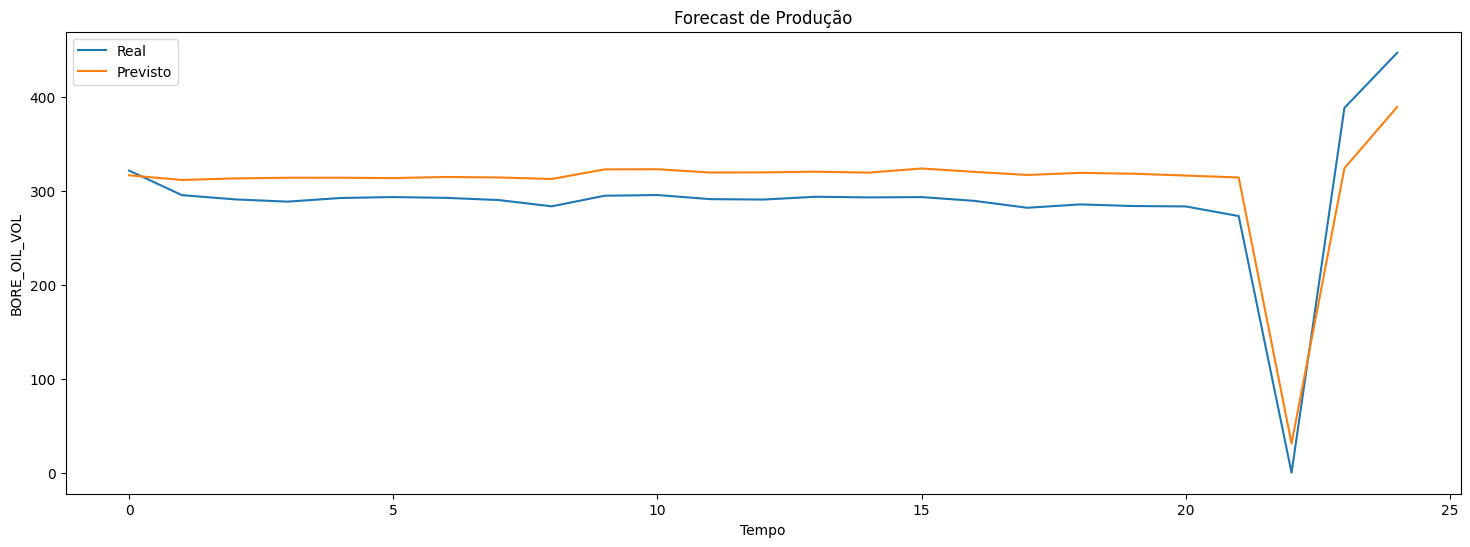

In [105]:
# ============================================================
# VISUALIZAÇÃO DAS PREVISÕES
# ============================================================

print("\n==============================")
print("GRÁFICO DE PREVISÃO")
print("==============================")

plt.figure(figsize=(18,6))

plt.plot(
    y_test.values,
    label="Real"
)

plt.plot(
    y_pred,
    label="Previsto"
)

plt.title("Forecast de Produção")

plt.xlabel("Tempo")

plt.ylabel(TARGET)

plt.legend()

plt.show()

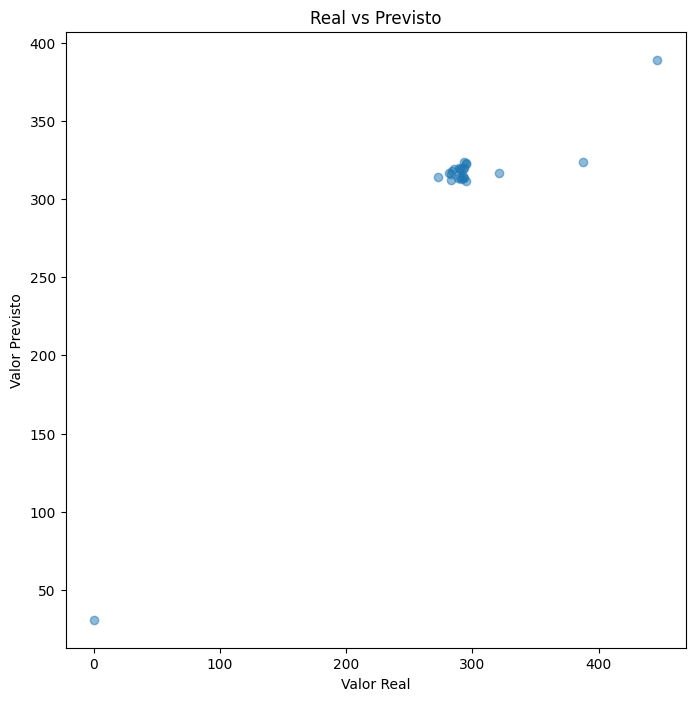

In [106]:
# ============================================================
# SCATTER REAL VS PREVISTO
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")

plt.title("Real vs Previsto")

plt.show()

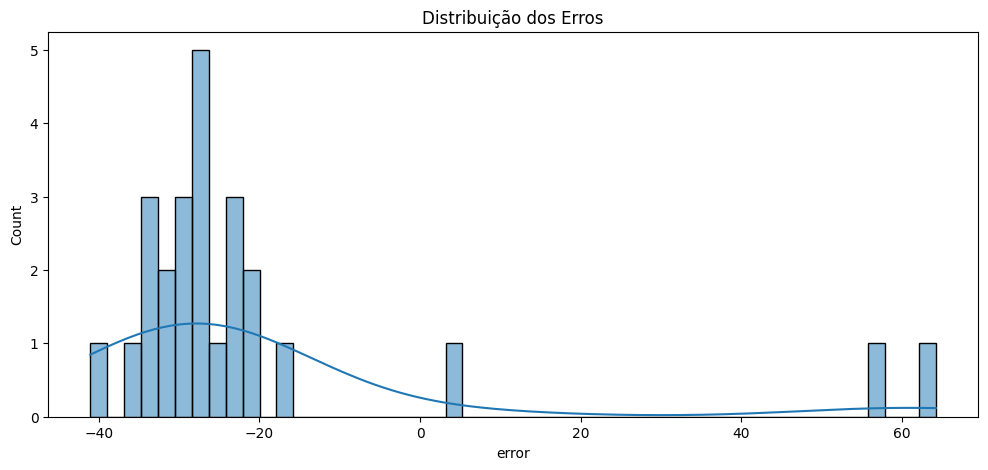

In [107]:
# ============================================================
# HISTOGRAMA DOS ERROS
# ============================================================

plt.figure(figsize=(12,5))

sns.histplot(
    results_df["error"],
    bins=50,
    kde=True
)

plt.title("Distribuição dos Erros")

plt.show()

In [108]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

print("\n==============================")
print("FEATURE IMPORTANCE")
print("==============================")

importance_df = pd.DataFrame({

    "feature": X.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

display(
    importance_df.head(20)
)


FEATURE IMPORTANCE


,feature,importance
43,oil_expanding_mean,0.417936
20,oil_roll_mean_3,0.229495
3,AVG_DP_TUBING,0.089337
8,oil_roll_30,0.045019
18,gas_lag_30,0.043996
12,water_lag_3,0.021985
33,oil_delta_3d,0.019603
50,water_vs_trend,0.018287
44,oil_expanding_std,0.011434
4,AVG_CHOKE_SIZE_P,0.010700


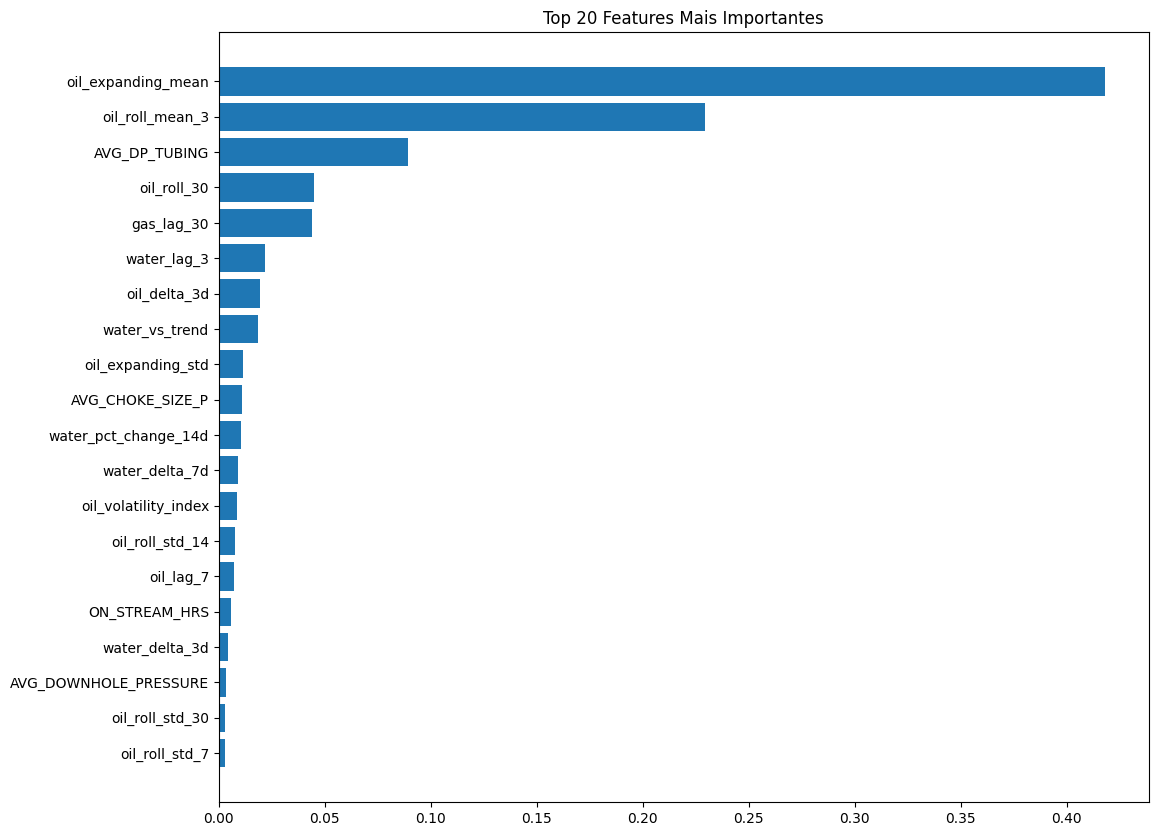

In [109]:
# ============================================================
# PLOT FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(12,10))

top_features = importance_df.head(20)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Features Mais Importantes")

plt.show()

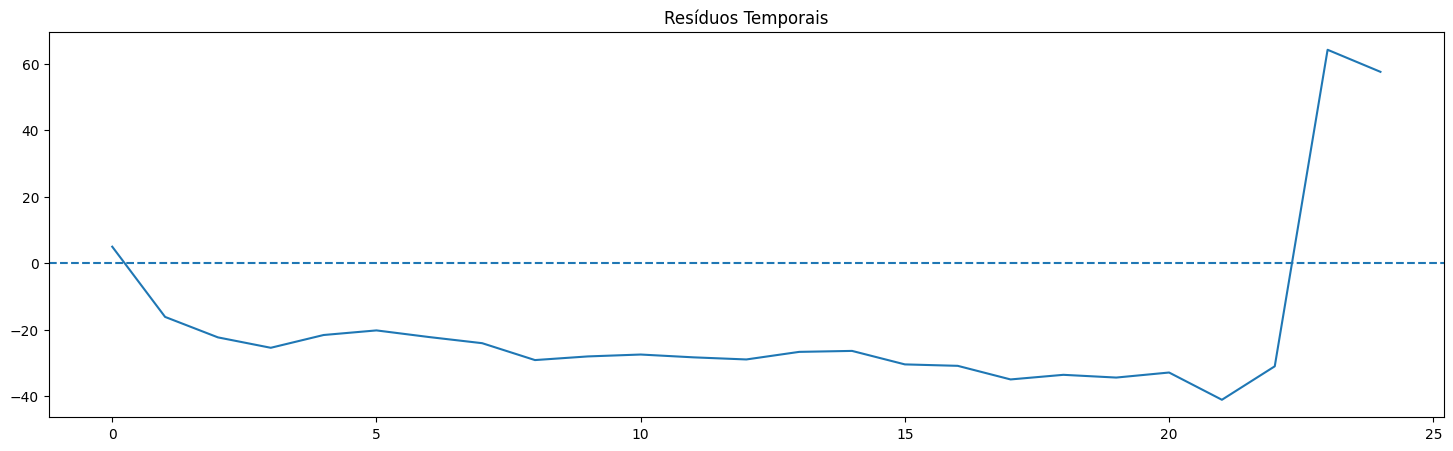

In [110]:
# ============================================================
# RESÍDUOS TEMPORAIS
# ============================================================

plt.figure(figsize=(18,5))

plt.plot(results_df["error"])

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Resíduos Temporais")

plt.show()

In [111]:
# ============================================================
# EXPORTAÇÃO DOS RESULTADOS
# ============================================================

results_df.to_csv(
    "forecast_results.csv",
    index=False
)

importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

print("\n==============================")
print("ARQUIVOS EXPORTADOS")
print("==============================")

print("forecast_results.csv")
print("feature_importance.csv")


ARQUIVOS EXPORTADOS
forecast_results.csv
feature_importance.csv


In [112]:
# ============================================================
# RESUMO FINAL
# ============================================================

print("\n==============================")
print("RESUMO FINAL")
print("==============================")

print(f"Target utilizado : {TARGET}")
print(f"Features usadas  : {X.shape[1]}")
print(f"Registros treino : {len(X_train)}")
print(f"Registros teste  : {len(X_test)}")

print("\nForecast concluído com sucesso.")


RESUMO FINAL
Target utilizado : BORE_OIL_VOL
Features usadas  : 55
Registros treino : 100
Registros teste  : 25

Forecast concluído com sucesso.


---
# FASE 06 — ANOMALY DETECTION
---

In [113]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [114]:
# ============================================================
# CONFIGURAÇÕES
# ============================================================

pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 200)

In [115]:
# ============================================================
# CARREGAMENTO DO DATASET
# ============================================================

df = pd.read_csv("volve_ml_ready.csv")

print("\nDataset carregado.")
print(df.shape)


Dataset carregado.
(125, 58)


In [116]:
# ============================================================
# IDENTIFICAÇÃO DE DATA
# ============================================================

date_columns = [col for col in df.columns if "date" in col.lower()]

if len(date_columns) > 0:

    date_col = date_columns[0]

    df[date_col] = pd.to_datetime(df[date_col])

    df = df.sort_values(date_col)

    print(f"\nColuna temporal encontrada: {date_col}")

else:

    date_col = None

    print("\nNenhuma coluna temporal encontrada.")


Coluna temporal encontrada: DATEPRD


In [117]:
# ============================================================
# ESCOLHA DA VARIÁVEL PRINCIPAL
# ============================================================

TARGET = "BORE_OIL_VOL"

if TARGET not in df.columns:

    raise Exception(
        f"\nA coluna '{TARGET}' não existe."
    )

print(f"\nTarget principal: {TARGET}")


Target principal: BORE_OIL_VOL


In [118]:
# ============================================================
# APENAS FEATURES NUMÉRICAS
# ============================================================

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove target da lista de features
features = [col for col in numeric_cols]

In [119]:
# ============================================================
# MATRIZ DE FEATURES
# ============================================================

X = df[features].copy()

In [120]:
# ============================================================
# ESCALONAMENTO
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nEscalonamento concluído.")


Escalonamento concluído.


In [121]:
# ============================================================
# ISOLATION FOREST
# ============================================================

print("\n==============================")
print("ISOLATION FOREST")
print("==============================")

model = IsolationForest(

    n_estimators=300,
    contamination=0.02,
    random_state=42

)

model.fit(X_scaled)


ISOLATION FOREST


IsolationForest(contamination=0.02, n_estimators=300, random_state=42)

In [122]:
# ============================================================
# PREDIÇÃO
# ============================================================

df["anomaly"] = model.predict(X_scaled)

# -1 = anomalia
#  1 = normal

df["anomaly_label"] = df["anomaly"].map({

    -1: "ANOMALY",
     1: "NORMAL"

})

In [123]:
# ============================================================
# SCORE DE ANOMALIA
# ============================================================

df["anomaly_score"] = model.decision_function(X_scaled)

# ============================================================
# RESUMO
# ============================================================

print("\n==============================")
print("RESUMO DE ANOMALIAS")
print("==============================")

print(df["anomaly_label"].value_counts())


RESUMO DE ANOMALIAS
anomaly_label
NORMAL     122
ANOMALY      3
Name: count, dtype: int64


In [124]:
# ============================================================
# TOP ANOMALIAS
# ============================================================

top_anomalies = df[df["anomaly"] == -1].copy()

top_anomalies = top_anomalies.sort_values(
    "anomaly_score"
)

print("\n==============================")
print("TOP ANOMALIAS")
print("==============================")

display(

    top_anomalies[
        [
            TARGET,
            "anomaly_score"
        ]
    ].head(20)

)


TOP ANOMALIAS


,BORE_OIL_VOL,anomaly_score
123,387.93,-0.022215
124,446.62,-0.017408
122,0.00,-0.016671



PLOT TEMPORAL


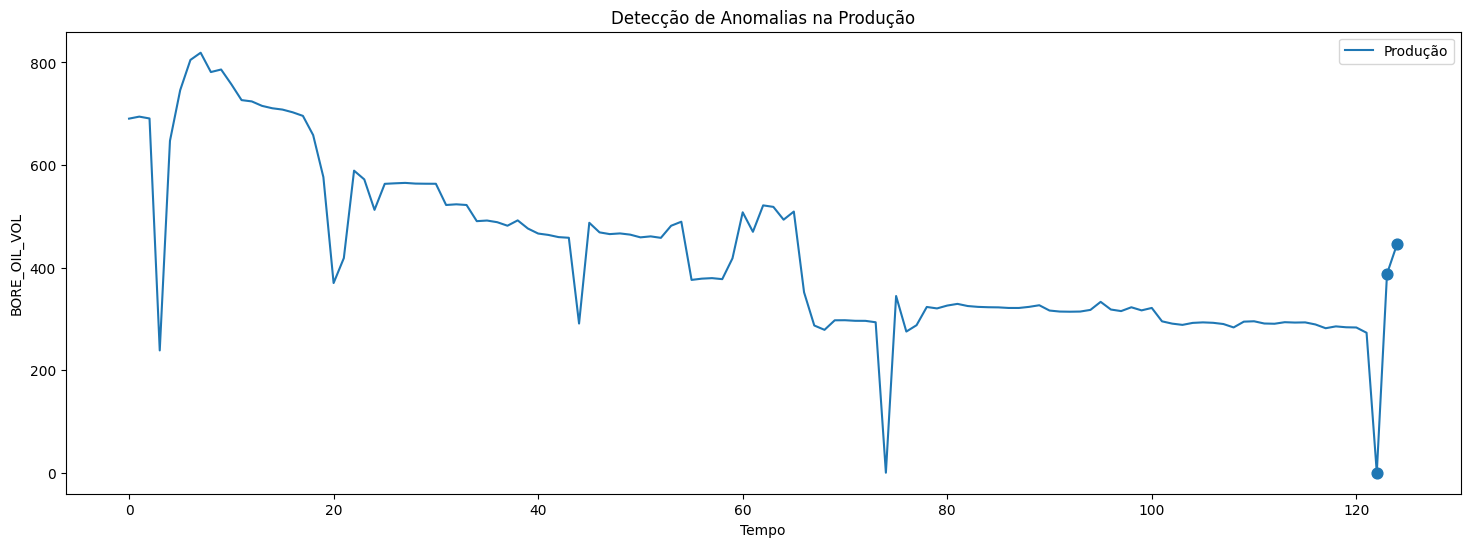

In [125]:
# ============================================================
# PLOT TEMPORAL
# ============================================================

print("\n==============================")
print("PLOT TEMPORAL")
print("==============================")

plt.figure(figsize=(18,6))

# Série principal
plt.plot(

    df[TARGET],
    label="Produção"

)

# Pontos anômalos
anomaly_points = df[df["anomaly"] == -1]

plt.scatter(

    anomaly_points.index,
    anomaly_points[TARGET],

    s=60

)

plt.title("Detecção de Anomalias na Produção")

plt.xlabel("Tempo")
plt.ylabel(TARGET)

plt.legend()

plt.show()

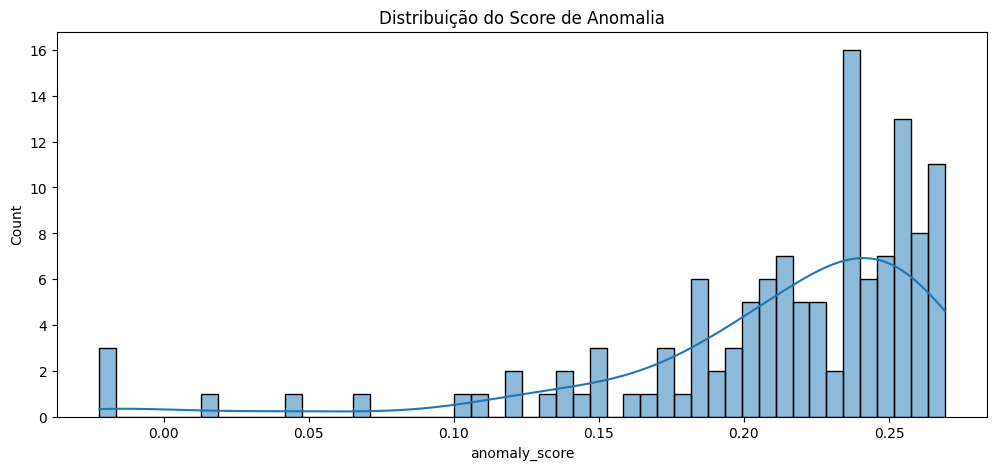

In [126]:
# ============================================================
# DISTRIBUIÇÃO DOS SCORES
# ============================================================

plt.figure(figsize=(12,5))

sns.histplot(

    df["anomaly_score"],
    bins=50,
    kde=True

)

plt.title("Distribuição do Score de Anomalia")

plt.show()

In [127]:
# ============================================================
# Z-SCORE TEMPORAL
# ============================================================

print("\n==============================")
print("Z-SCORE TEMPORAL")
print("==============================")

mean_target = df[TARGET].mean()

std_target = df[TARGET].std()

df["zscore"] = (

    (df[TARGET] - mean_target) /
    std_target

)

# Threshold clássico
threshold = 3

df["zscore_anomaly"] = (

    np.abs(df["zscore"]) > threshold

)

print(

    f"Quantidade de anomalias Z-Score: "
    f"{df['zscore_anomaly'].sum()}"

)



Z-SCORE TEMPORAL
Quantidade de anomalias Z-Score: 0


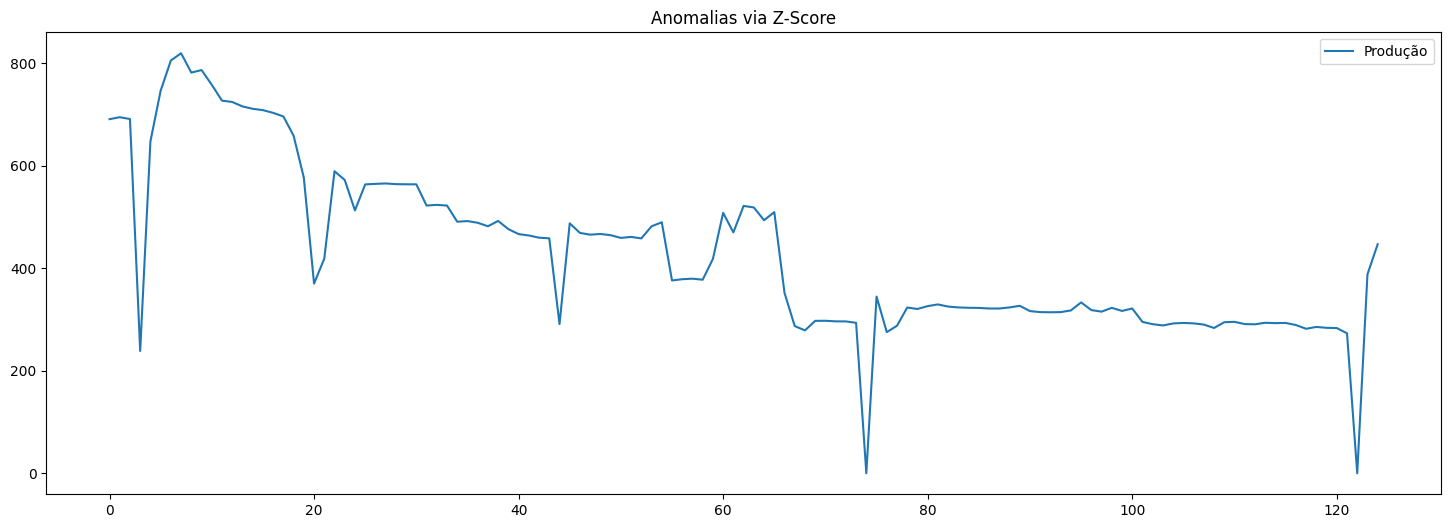

In [128]:
# ============================================================
# PLOT Z-SCORE
# ============================================================

plt.figure(figsize=(18,6))

plt.plot(

    df[TARGET],
    label="Produção"

)

z_anomalies = df[df["zscore_anomaly"]]

plt.scatter(

    z_anomalies.index,
    z_anomalies[TARGET],

    s=60

)

plt.title("Anomalias via Z-Score")

plt.legend()

plt.show()

In [129]:
# ============================================================
# ROLLING MEAN ANOMALY
# ============================================================

print("\n==============================")
print("ROLLING ANOMALY DETECTION")
print("==============================")

window = 30

df["rolling_mean"] = (

    df[TARGET]
    .rolling(window)
    .mean()

)

df["rolling_std"] = (

    df[TARGET]
    .rolling(window)
    .std()

)

df["upper_band"] = (

    df["rolling_mean"] +
    2 * df["rolling_std"]

)

df["lower_band"] = (

    df["rolling_mean"] -
    2 * df["rolling_std"]

)

df["rolling_anomaly"] = (

    (df[TARGET] > df["upper_band"]) |
    (df[TARGET] < df["lower_band"])

)

print(

    f"Rolling anomalies: "
    f"{df['rolling_anomaly'].sum()}"

)


ROLLING ANOMALY DETECTION
Rolling anomalies: 7


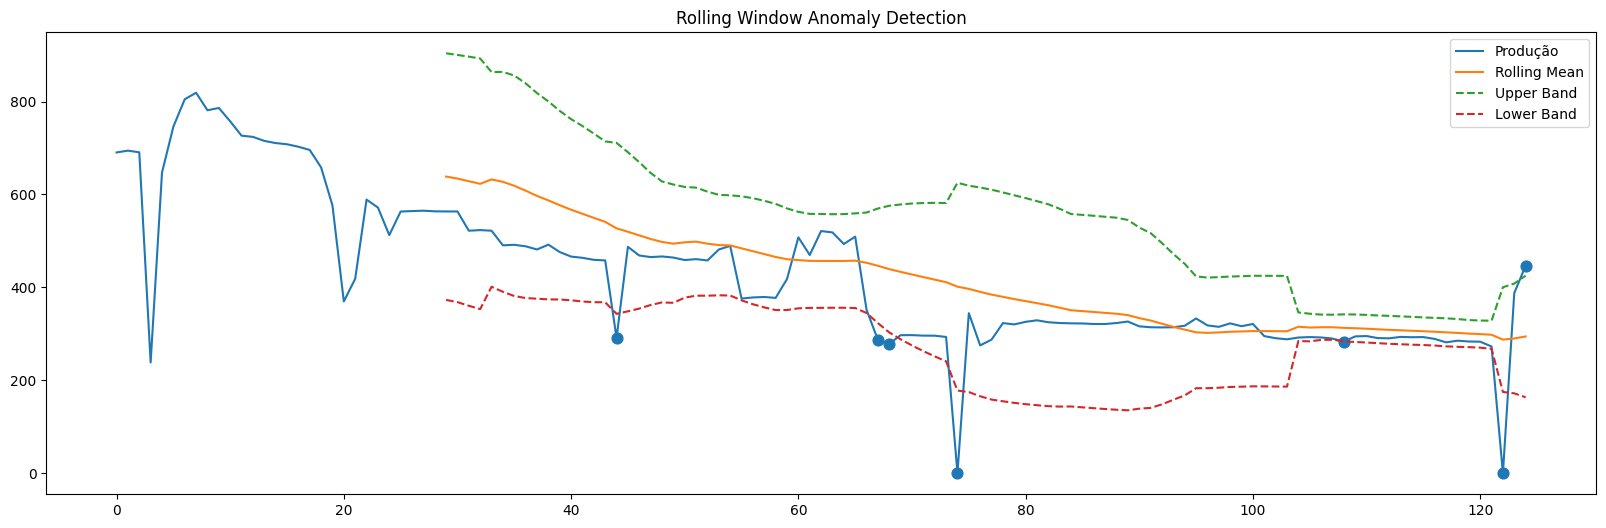

In [130]:
# ============================================================
# PLOT ROLLING BANDS
# ============================================================

plt.figure(figsize=(20,6))

plt.plot(

    df[TARGET],
    label="Produção"

)

plt.plot(

    df["rolling_mean"],
    label="Rolling Mean"

)

plt.plot(

    df["upper_band"],
    linestyle="--",
    label="Upper Band"

)

plt.plot(

    df["lower_band"],
    linestyle="--",
    label="Lower Band"

)

rolling_points = df[df["rolling_anomaly"]]

plt.scatter(

    rolling_points.index,
    rolling_points[TARGET],

    s=60

)

plt.title("Rolling Window Anomaly Detection")

plt.legend()

plt.show()

In [131]:
# ============================================================
# CRIAÇÃO DO DATASET FINAL DE ANOMALIAS
# ============================================================

anomaly_dataset = df[

    (
        (df["anomaly"] == -1) |
        (df["zscore_anomaly"]) |
        (df["rolling_anomaly"])
    )

].copy()

In [132]:
# ============================================================
# SEVERIDADE
# ============================================================

anomaly_dataset["severity"] = (

    np.abs(anomaly_dataset["zscore"])

)

In [133]:
# ============================================================
# RANKING DE SEVERIDADE
# ============================================================

anomaly_dataset = anomaly_dataset.sort_values(

    "severity",
    ascending=False

)

In [134]:
# ============================================================
# TOP EVENTOS
# ============================================================

print("\n==============================")
print("TOP EVENTOS ANÔMALOS")
print("==============================")

cols_to_show = [

    TARGET,
    "anomaly_score",
    "zscore",
    "severity"

]

available_cols = [

    col for col in cols_to_show
    if col in anomaly_dataset.columns

]

display(

    anomaly_dataset[
        available_cols
    ].head(20)

)


TOP EVENTOS ANÔMALOS


,BORE_OIL_VOL,anomaly_score,zscore,severity
74,0.00,0.018060,-2.662211,2.662211
122,0.00,-0.016671,-2.662211,2.662211
68,278.58,0.221924,-0.932360,0.932360
108,283.28,0.249413,-0.903175,0.903175
67,287.03,0.211254,-0.879889,0.879889
44,290.87,0.149088,-0.856045,0.856045
123,387.93,-0.022215,-0.253347,0.253347
124,446.62,-0.017408,0.111090,0.111090


In [135]:
# ============================================================
# EXPORTAÇÃO
# ============================================================

anomaly_dataset.to_csv(

    "detected_anomalies.csv",
    index=False

)

df.to_csv(

    "full_anomaly_analysis.csv",
    index=False

)

print("\n==============================")
print("ARQUIVOS EXPORTADOS")
print("==============================")

print("detected_anomalies.csv")
print("full_anomaly_analysis.csv")


ARQUIVOS EXPORTADOS
detected_anomalies.csv
full_anomaly_analysis.csv


In [136]:
# ============================================================
# RESUMO FINAL
# ============================================================

print("\n==============================")
print("RESUMO FINAL")
print("==============================")

print(f"Total de registros : {len(df)}")

print(
    f"Isolation anomalies: "
    f"{(df['anomaly'] == -1).sum()}"
)

print(
    f"Z-score anomalies : "
    f"{df['zscore_anomaly'].sum()}"
)

print(
    f"Rolling anomalies : "
    f"{df['rolling_anomaly'].sum()}"
)

print(
    f"Eventos consolidados: "
    f"{len(anomaly_dataset)}"
)

print("\nFASE 06 CONCLUÍDA.")


RESUMO FINAL
Total de registros : 125
Isolation anomalies: 3
Z-score anomalies : 0
Rolling anomalies : 7
Eventos consolidados: 8

FASE 06 CONCLUÍDA.


---
# FASE 07 — PRODUCTION DIAGNOSTICS
---

In [137]:
# ============================================================
# CARREGAMENTO
# ============================================================

df = pd.read_csv("volve_ml_ready.csv")

print("\nDataset carregado.")
print(df.shape)


Dataset carregado.
(125, 58)


In [138]:
# ============================================================
# IDENTIFICAÇÃO DE DATA
# ============================================================

date_columns = [col for col in df.columns if "date" in col.lower()]

if len(date_columns) > 0:

    date_col = date_columns[0]

    df[date_col] = pd.to_datetime(df[date_col])

    df = df.sort_values(date_col)

    print(f"\nColuna temporal encontrada: {date_col}")

else:

    date_col = None

    print("\nNenhuma coluna temporal encontrada.")


Coluna temporal encontrada: DATEPRD


In [139]:
# ============================================================
# TARGET PRINCIPAL
# ============================================================

TARGET = "BORE_OIL_VOL"

if TARGET not in df.columns:

    raise Exception(
        f"\nColuna '{TARGET}' não encontrada."
    )

print(f"\nTarget principal: {TARGET}")


Target principal: BORE_OIL_VOL


In [140]:
# ============================================================
# CRIAÇÃO DE FEATURES DIAGNÓSTICAS
# ============================================================

print("\n==============================")
print("FEATURES DIAGNÓSTICAS")
print("==============================")

# ------------------------------------------------------------
# MÉDIAS TEMPORAIS
# ------------------------------------------------------------

df["prod_mean_7"] = (
    df[TARGET]
    .rolling(7)
    .mean()
)

df["prod_mean_30"] = (
    df[TARGET]
    .rolling(30)
    .mean()
)

# ------------------------------------------------------------
# VOLATILIDADE
# ------------------------------------------------------------

df["prod_std_7"] = (
    df[TARGET]
    .rolling(7)
    .std()
)

df["prod_std_30"] = (
    df[TARGET]
    .rolling(30)
    .std()
)

# ------------------------------------------------------------
# DECLÍNIO DE PRODUÇÃO
# ------------------------------------------------------------

df["decline_rate"] = (

    (
        df["prod_mean_7"] -
        df["prod_mean_30"]
    )
    /
    df["prod_mean_30"]

)

# ------------------------------------------------------------
# VARIABILIDADE
# ------------------------------------------------------------

df["volatility_ratio"] = (

    df["prod_std_7"] /
    df["prod_std_30"]

)

# ------------------------------------------------------------
# EFICIÊNCIA OPERACIONAL
# ------------------------------------------------------------

max_prod = df[TARGET].max()

df["efficiency_score"] = (

    df[TARGET] / max_prod

)



FEATURES DIAGNÓSTICAS


In [141]:
# ============================================================
# LIMPEZA
# ============================================================

df_diag = df.dropna().copy()

print("\nDataset diagnóstico:")
print(df_diag.shape)


Dataset diagnóstico:
(96, 65)


In [142]:
# ============================================================
# SCORE DE DEGRADAÇÃO
# ============================================================

print("\n==============================")
print("SCORE DE DEGRADAÇÃO")
print("==============================")

# Quanto menor, pior
df_diag["degradation_score"] = (

    (
        1 - df_diag["decline_rate"]
    ) *
    df_diag["efficiency_score"]

)


SCORE DE DEGRADAÇÃO


In [143]:
# ============================================================
# SCORE DE ESTABILIDADE
# ============================================================

# Quanto menor volatilidade, melhor
df_diag["stability_score"] = (

    1 /
    (
        1 +
        df_diag["volatility_ratio"]
    )

)

In [144]:
# ============================================================
# SCORE OPERACIONAL FINAL
# ============================================================

df_diag["operational_score"] = (

    (
        df_diag["degradation_score"] * 0.6
    )
    +
    (
        df_diag["stability_score"] * 0.4
    )

)

In [145]:
# ============================================================
# NORMALIZAÇÃO
# ============================================================

min_score = df_diag["operational_score"].min()

max_score = df_diag["operational_score"].max()

df_diag["operational_score_normalized"] = (

    (
        df_diag["operational_score"] -
        min_score
    )
    /
    (
        max_score -
        min_score
    )

)

In [146]:
# ============================================================
# CLASSIFICAÇÃO OPERACIONAL
# ============================================================

print("\n==============================")
print("CLASSIFICAÇÃO OPERACIONAL")
print("==============================")

conditions = [

    (
        df_diag["operational_score_normalized"] >= 0.70
    ),

    (
        (
            df_diag["operational_score_normalized"] >= 0.40
        )
        &
        (
            df_diag["operational_score_normalized"] < 0.70
        )
    ),

    (
        df_diag["operational_score_normalized"] < 0.40
    )

]

choices = [

    "NORMAL",
    "WARNING",
    "CRITICAL"

]

df_diag["operational_status"] = np.select(

    conditions,
    choices,
    default="UNKNOWN"

)

print(

    df_diag["operational_status"]
    .value_counts()

)


CLASSIFICAÇÃO OPERACIONAL
operational_status
WARNING     60
NORMAL      31
CRITICAL     5
Name: count, dtype: int64


In [147]:
# ============================================================
# TOP EVENTOS CRÍTICOS
# ============================================================

critical_df = df_diag[

    df_diag["operational_status"] == "CRITICAL"

].copy()

critical_df = critical_df.sort_values(

    "operational_score_normalized"

)

print("\n==============================")
print("TOP EVENTOS CRÍTICOS")
print("==============================")

cols_to_show = [

    TARGET,
    "decline_rate",
    "volatility_ratio",
    "efficiency_score",
    "operational_score_normalized",
    "operational_status"

]

display(

    critical_df[
        cols_to_show
    ].head(20)

)


TOP EVENTOS CRÍTICOS


,BORE_OIL_VOL,decline_rate,volatility_ratio,efficiency_score,operational_score_normalized,operational_status
122,0.00,-0.157844,1.899067,0.000000,0.000000,CRITICAL
74,0.00,-0.374318,0.993072,0.000000,0.092996,CRITICAL
68,278.58,-0.037729,1.645665,0.340192,0.333661,CRITICAL
67,287.03,0.008097,1.506098,0.350511,0.341382,CRITICAL
69,297.19,-0.098346,1.535502,0.362918,0.383952,CRITICAL



PLOT SCORE OPERACIONAL


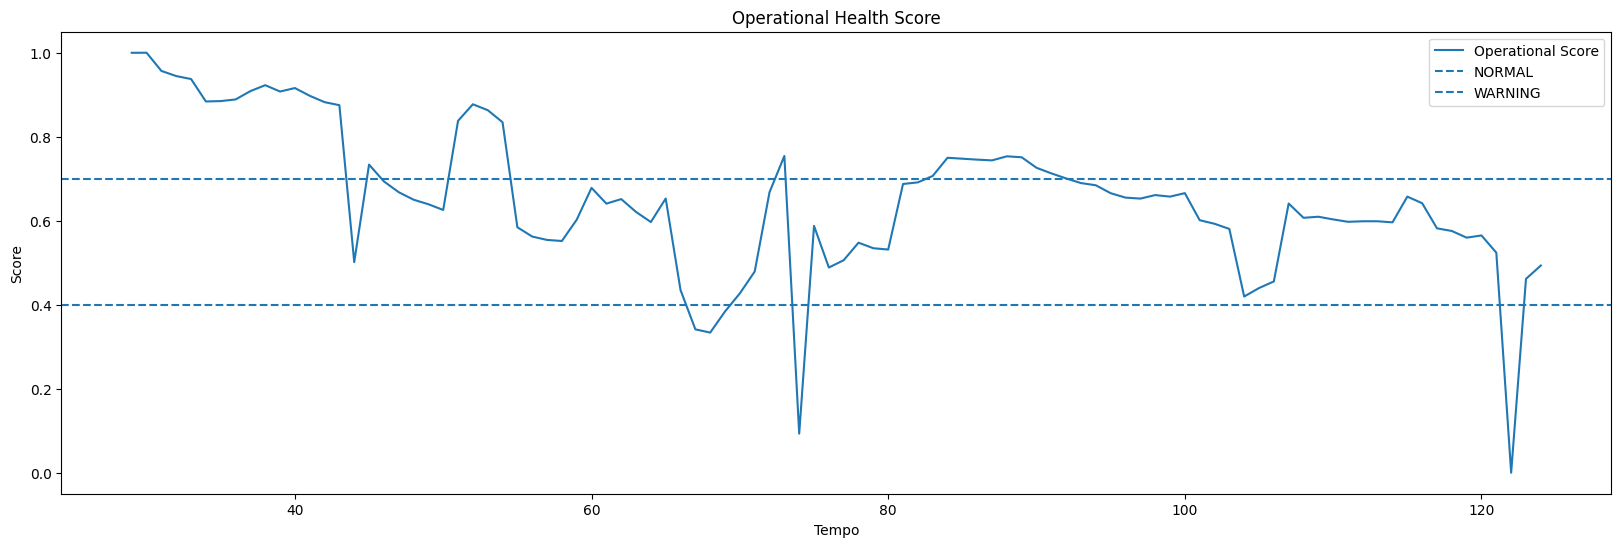

In [148]:
# ============================================================
# PLOT TEMPORAL DO SCORE OPERACIONAL
# ============================================================

print("\n==============================")
print("PLOT SCORE OPERACIONAL")
print("==============================")

plt.figure(figsize=(20,6))

plt.plot(

    df_diag["operational_score_normalized"],
    label="Operational Score"

)

plt.axhline(
    y=0.70,
    linestyle="--",
    label="NORMAL"
)

plt.axhline(
    y=0.40,
    linestyle="--",
    label="WARNING"
)

plt.title("Operational Health Score")

plt.xlabel("Tempo")
plt.ylabel("Score")

plt.legend()

plt.show()


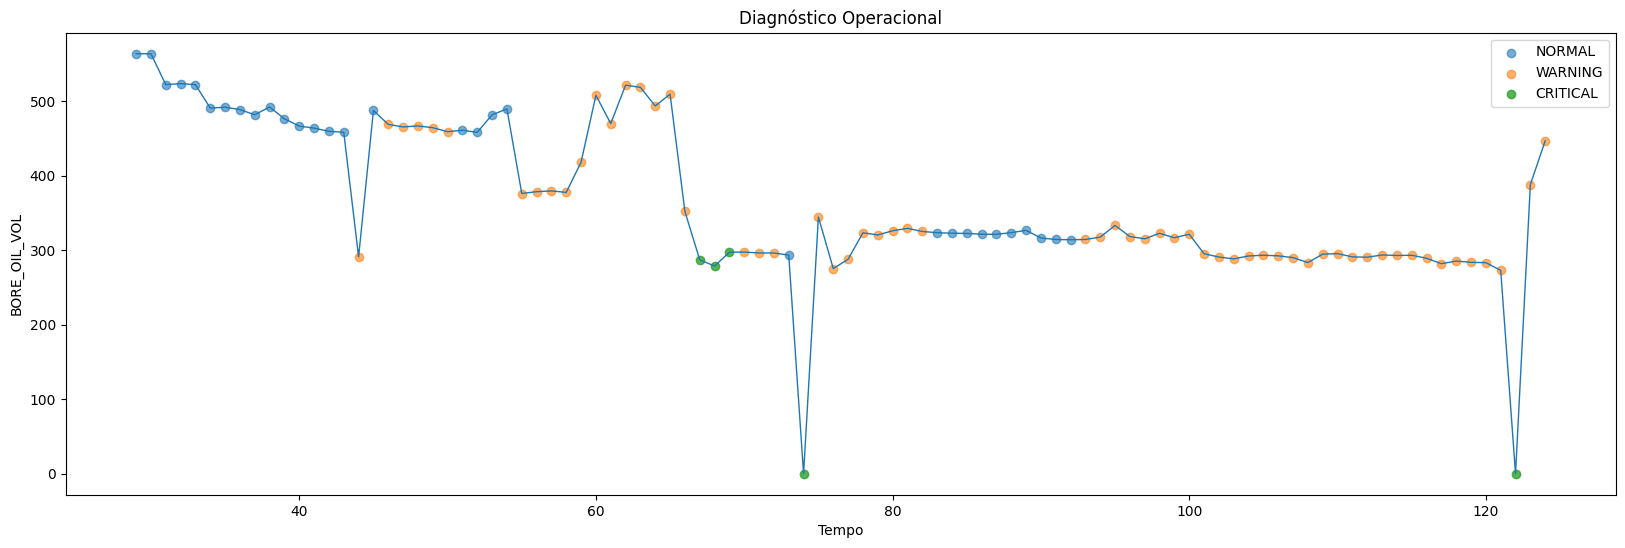

In [149]:
# ============================================================
# PLOT DE PRODUÇÃO COM STATUS
# ============================================================

plt.figure(figsize=(20,6))

# NORMAL
normal_points = df_diag[
    df_diag["operational_status"] == "NORMAL"
]

plt.scatter(

    normal_points.index,
    normal_points[TARGET],

    label="NORMAL",
    alpha=0.6

)

# WARNING
warning_points = df_diag[
    df_diag["operational_status"] == "WARNING"
]

plt.scatter(

    warning_points.index,
    warning_points[TARGET],

    label="WARNING",
    alpha=0.6

)

# CRITICAL
critical_points = df_diag[
    df_diag["operational_status"] == "CRITICAL"
]

plt.scatter(

    critical_points.index,
    critical_points[TARGET],

    label="CRITICAL",
    alpha=0.8

)

plt.plot(

    df_diag[TARGET],
    linewidth=1

)

plt.title("Diagnóstico Operacional")

plt.xlabel("Tempo")
plt.ylabel(TARGET)

plt.legend()

plt.show()

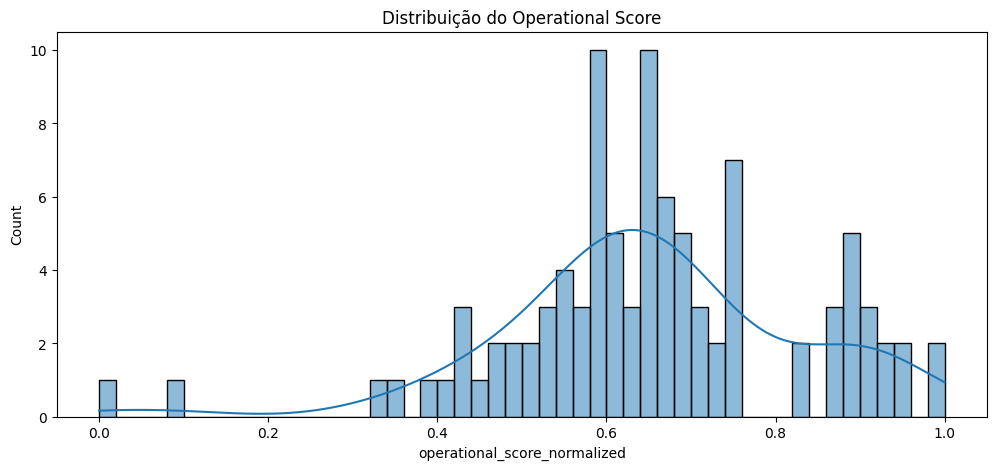

In [150]:
# ============================================================
# DISTRIBUIÇÃO DOS SCORES
# ============================================================

plt.figure(figsize=(12,5))

sns.histplot(

    df_diag["operational_score_normalized"],
    bins=50,
    kde=True

)

plt.title("Distribuição do Operational Score")

plt.show()

In [151]:
# ============================================================
# RANKING OPERACIONAL
# ============================================================

ranking_df = df_diag.sort_values(

    "operational_score_normalized"

)

print("\n==============================")
print("RANKING OPERACIONAL")
print("==============================")

display(

    ranking_df[
        cols_to_show
    ].head(30)

)


RANKING OPERACIONAL


,BORE_OIL_VOL,decline_rate,volatility_ratio,efficiency_score,operational_score_normalized,operational_status
122,0.00,-0.157844,1.899067,0.000000,0.000000,CRITICAL
74,0.00,-0.374318,0.993072,0.000000,0.092996,CRITICAL
68,278.58,-0.037729,1.645665,0.340192,0.333661,CRITICAL
67,287.03,0.008097,1.506098,0.350511,0.341382,CRITICAL
69,297.19,-0.098346,1.535502,0.362918,0.383952,CRITICAL
104,292.13,-0.036657,1.009832,0.356739,0.419517,WARNING
70,297.33,-0.160272,1.308927,0.363089,0.427076,WARNING
66,351.80,0.063274,1.107143,0.429606,0.434897,WARNING
105,293.13,-0.044811,0.903783,0.357960,0.439677,WARNING
106,292.29,-0.057566,0.829422,0.356934,0.455437,WARNING


In [152]:
# ============================================================
# KPI GERAIS
# ============================================================

print("\n==============================")
print("KPIs OPERACIONAIS")
print("==============================")

normal_pct = (
    (
        df_diag["operational_status"] == "NORMAL"
    ).mean()
) * 100

warning_pct = (
    (
        df_diag["operational_status"] == "WARNING"
    ).mean()
) * 100

critical_pct = (
    (
        df_diag["operational_status"] == "CRITICAL"
    ).mean()
) * 100

print(f"NORMAL  : {normal_pct:.2f}%")
print(f"WARNING : {warning_pct:.2f}%")
print(f"CRITICAL: {critical_pct:.2f}%")


KPIs OPERACIONAIS
NORMAL  : 32.29%
CRITICAL: 5.21%


In [153]:
# ============================================================
# EXPORTAÇÃO
# ============================================================

df_diag.to_csv(

    "production_diagnostics.csv",
    index=False

)

ranking_df.to_csv(

    "production_ranking.csv",
    index=False

)

critical_df.to_csv(

    "critical_events.csv",
    index=False

)

print("\n==============================")
print("ARQUIVOS EXPORTADOS")
print("==============================")

print("production_diagnostics.csv")
print("production_ranking.csv")
print("critical_events.csv")


ARQUIVOS EXPORTADOS
production_diagnostics.csv
production_ranking.csv
critical_events.csv


In [154]:
# ============================================================
# RESUMO FINAL
# ============================================================

print("\n==============================")
print("RESUMO FINAL")
print("==============================")

print(f"Total de registros: {len(df_diag)}")

print(
    f"Eventos NORMAL  : "
    f"{(df_diag['operational_status'] == 'NORMAL').sum()}"
)

print(
    f"Eventos WARNING : "
    f"{(df_diag['operational_status'] == 'WARNING').sum()}"
)

print(
    f"Eventos CRITICAL: "
    f"{(df_diag['operational_status'] == 'CRITICAL').sum()}"
)

print("\nFASE 07 CONCLUÍDA.")


RESUMO FINAL
Total de registros: 96
Eventos NORMAL  : 31
Eventos WARNING : 60
Eventos CRITICAL: 5

FASE 07 CONCLUÍDA.


---
# FASE 08 — ROOT CAUSE ANALYTICS
---